In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from modules.coord_transform import *
from modules.simulation import *
from modules.likelihood import *
from modules.mcmc import run_mcmc  
from modules.localise import ci_68_and_sigma
from modules.constellation import get_satellite_positions,generate_full_constellation,get_pointing_radec,eci_to_latlon
#from modules.constellation_copy import HermesConstellation,get_satellite_positions,get_pointing_radec,eci_to_latlon


import os
from matplotlib.patches import Patch

In [2]:
def catalogue(type):
    if type =="short":
        cat = pd.read_csv("D:\\Unimelb\\SpIRIT_In_Polar_Orbit\\mcmc\\others\\short_grb_catalogue_filter.txt",sep ='|')
    elif type=="long":
        cat = pd.read_csv("D:\\Unimelb\\SpIRIT_In_Polar_Orbit\\mcmc\\others\\long_grb_catalogue_filter.txt", sep='|' )
    return cat

In [ ]:
np.random.seed(4)
offset_angle = [10]
# angular_spacing = 10
type ="long"
flux_limit = flux_lower_bound(type) # Change flux_limit for long grb = 0.463 and for short grb= 1.861
cat = catalogue(type)
df_results_ = {}
for i, offset in enumerate(offset_angle):
    # sat_pointing = sat_pointing_positions(offset)
    A = 50
    localisation_result = []
    n_det = 0
    total_generate = 0  # Counter for total GRBs generated

    minimum_num_sats_detecting_burst = 3

    while n_det < 5: # change here to set the number of detection
        t_random = np.random.uniform(0, 96 * 60)
        # sat_pos = generate_full_constellation(t_random)
        # lat_lon = eci_to_latlon(sat_pos, t_random)
        sat_pos = get_satellite_positions(t_random, num_sats=8, angular_spacing_deg=45, inclination_deg=0, group_rotation_deg=0)
        lat_lon = eci_to_latlon(sat_pos, t_random)
        for i, (lat, lon) in enumerate(lat_lon):
                bkgd_val = get_particle_background_value(lat, lon)
                print(f"Sat {i}: lat={lat}, lon={lon}, bkgd_val={bkgd_val}")
        pointings, base_dirs = get_pointing_radec(sat_pos,num_sats=8, angular_offset_deg =offset_angle)

        sat_pointing = np.array([coord_transform.r2c(ra, dec) for ra, dec in np.degrees(pointings)])

        grb_vec, ra, dec, t_90, flux_avg = generate_grb(cat)
        
        total_generate += 1

        grb_info = {"ra": ra, 
                "dec":dec, 
                "flux_avg":flux_avg, 
                "t_90": t_90}  
        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
        print(det_result)
        sat_info = {'sat_pos' : sat_pos,
                'sat_pointing': sat_pointing, 
                'flux_limit': flux_limit,
                'offset': offset,
                'lat_lon':lat_lon}

        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
    
        if sum( det_result[0] > 0 ) >=  minimum_num_sats_detecting_burst :  # Ensure it skips GRBs that do not meet conditions
        
            print(ra, dec)
            n_det += 1
            f_obs, t_obs, occult = det_result # changed here.................
            print("Detection result:", f_obs)

            Ph_obs = np.array([ 0 if f < flux_limit 
                            else np.random.poisson(f * t_90 * A) for f in f_obs])  # Observed Photon count
            
            save_path = os.path.join( f"./orbit_results/8_{type}_grb_plots", f"offset_{offset}", f"detection_{n_det}")
            
            obs_info = {'t_obs': t_obs,
                    'f_obs': f_obs,
                    'Ph_obs': Ph_obs }
        
            mcmc_params= {'steps': 5000, 
                      'nwalk': 8, 
                      'discard': 1000,
                      'move': 2, 
                      'save_path': save_path,
                      'corner_show' :False ,'corner_save' : True, 
                      'chain_show': False, 'chain_save' : True}
            
            localise_params ={'localisation_show' :False, 'localisation_save' :True}
        
            flat_samples = run_mcmc(**grb_info,
                                        **obs_info,
                                        **sat_info,
                                        **mcmc_params)
            
            true_value = np.array([ra, dec, flux_avg])
            
            ci_area_68, containment, area_per_grid_point, std_dev = ci_68_and_sigma(flat_samples,
                                                      true_value, 
                                                      type,
                                                      offset,
                                                      save_path,
                                                      **localise_params)
                                                        

            print(f'RA:{ra},DEC:{dec},FLUX:{flux_avg}')
            print(f"68% confidence region area: {ci_area_68:.2f} deg²")
            print(f"area of grid:{area_per_grid_point}deg²")
            print(f"std_dev:{std_dev}")
            print(f'Localization completed for detection #{n_det}')    
        
            localisation_result.append([ra, dec, t_90, flux_avg, t_random, f_obs, np.count_nonzero(f_obs), ci_area_68, containment, total_generate])

        df_results_[i] = pd.DataFrame(localisation_result, columns=['RA', 'Dec', 'T90', 'Flux_Avg', 'Time', 'fcos','n_det' ,'CI_Area_68', 'containment','Total generated'])
    
df_results_[i].to_csv(f'./orbit_results/8_{type}_grb_plots/{type}_{offset}.csv', index=False)
#print(f'Total GRBs generated: {total_generate}, Total detected: {n_det}')

Sat 0: lat=-0.0, lon=-35.14154190404304, bkgd_val=0.0
Sat 1: lat=0.0, lon=9.858458095956962, bkgd_val=0.0
Sat 2: lat=0.0, lon=54.85845809595696, bkgd_val=0.0
Sat 3: lat=0.0, lon=99.8584580959569, bkgd_val=0.0
Sat 4: lat=0.0, lon=144.85845809595696, bkgd_val=0.0
Sat 5: lat=-0.0, lon=-170.141541904043, bkgd_val=0.0
Sat 6: lat=-0.0, lon=-125.14154190404307, bkgd_val=0.0
Sat 7: lat=-0.0, lon=-80.1415419040431, bkgd_val=0.0
(array([0., 0., 0., 0., 0., 0., 0., 0.]), array([-3.26694542e-06, -1.92138822e-06,  5.49692140e-07,  2.69877030e-06,
        3.26694542e-06,  1.92138822e-06, -5.49692140e-07, -2.69877030e-06]))
Sat 0: lat=-0.0, lon=175.25560338961964, bkgd_val=0.0
Sat 1: lat=-0.0, lon=-139.74439661038042, bkgd_val=0.0
Sat 2: lat=-0.0, lon=-94.74439661038036, bkgd_val=0.0
Sat 3: lat=-0.0, lon=-49.74439661038042, bkgd_val=0.0
Sat 4: lat=0.0, lon=-4.744396610380363, bkgd_val=0.0
Sat 5: lat=0.0, lon=40.25560338961958, bkgd_val=0.0
Sat 6: lat=0.0, lon=85.25560338961964, bkgd_val=0.0
Sat 7: la

100%|██████████| 5000/5000 [00:13<00:00, 361.21it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

68% confidence region area: 3.00 deg²
True value lies within 1σ (68%) confidence region.
RA:118.46080238089625,DEC:6.728367255997412,FLUX:3.28808
68% confidence region area: 3.00 deg²
area of grid:0.2369282547267339deg²
std_dev:0.4738545093858978
Localization completed for detection #3
Sat 0: lat=-0.0, lon=-158.3158346180568, bkgd_val=0.0
Sat 1: lat=-0.0, lon=-113.31583461805678, bkgd_val=0.0
Sat 2: lat=-0.0, lon=-68.31583461805684, bkgd_val=0.0
Sat 3: lat=-0.0, lon=-23.315834618056783, bkgd_val=5.2613
Sat 4: lat=0.0, lon=21.68416538194316, bkgd_val=0.0
Sat 5: lat=0.0, lon=66.68416538194322, bkgd_val=0.0
Sat 6: lat=0.0, lon=111.68416538194322, bkgd_val=0.0
Sat 7: lat=0.0, lon=156.68416538194322, bkgd_val=0.0
(array([0., 0., 0., 0., 0., 0., 0., 0.]), array([-1.39816219e-06,  1.15097841e-06,  3.02589146e-06,  3.12827833e-06,
        1.39816219e-06, -1.15097841e-06, -3.02589146e-06, -3.12827833e-06]))
Sat 0: lat=-0.0, lon=-38.85282642575902, bkgd_val=0.0
Sat 1: lat=0.0, lon=6.147173574240

 93%|█████████▎| 4646/5000 [00:36<00:01, 296.06it/s]Traceback (most recent call last):
  File "c:\Users\Haritha\anaconda3\Lib\site-packages\emcee\ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Haritha\repo\grb_localisation\mcmc\modules\likelihood.py", line 232, in log_probability
    log_probability = lp + log_likelihood(theta, t_obs, f_obs, t_90, Ph_obs, sat_pos, sat_pointing, flux_limit, offset,lat_lon )
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Haritha\repo\grb_localisation\mcmc\modules\likelihood.py", line 174, in log_likelihood
    f_pred, t_pred  = simulate_satellite_det(d_guess, f_guess, sat_pos, sat_pointing, flux_limit, lat_lon)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Haritha\repo\grb_localis

emcee: Exception while calling your likelihood function:
  params: [96.04855231 38.25642797  4.74338561]
  args: (94.82990294373235, array([ 1.83931312e-06,  2.57834777e-06,  1.80702127e-06, -2.28337809e-08,
       -1.83931312e-06, -2.57834777e-06, -1.80702127e-06,  2.28337809e-08]), array([0.        , 0.        , 0.        , 0.        , 1.82319169,
       3.78954731, 0.94076086, 0.64205751]), 18.432, array([   0,    0,    0,    0, 1761, 3477,  854,  646]), array([[-0.6382668 , -0.76981523, -0.        ],
       [ 0.09301879, -0.99566435, -0.        ],
       [ 0.76981523, -0.6382668 , -0.        ],
       [ 0.99566435,  0.09301879,  0.        ],
       [ 0.6382668 ,  0.76981523,  0.        ],
       [-0.09301879,  0.99566435,  0.        ],
       [-0.76981523,  0.6382668 ,  0.        ],
       [-0.99566435, -0.09301879, -0.        ]]), array([[ 6.63068584e-02,  9.97799279e-01, -1.82765817e-15],
       [-2.83633279e-01, -9.58932825e-01,  1.82765817e-15],
       [-8.39071529e-01, -1.0381

KeyboardInterrupt: 

In [5]:
np.random.seed(2)
offset_angle = [20]
# angular_spacing = 10
type ="long"
flux_limit = flux_lower_bound(type) # Change flux_limit for long grb = 0.463 and for short grb= 1.861
cat = catalogue(type)
df_results_ = {}
for i, offset in enumerate(offset_angle):
    # sat_pointing = sat_pointing_positions(offset)
    A = 50
    localisation_result = []
    n_det = 0
    total_generate = 0  # Counter for total GRBs generated

    minimum_num_sats_detecting_burst = 3

    while n_det < 50: # change here to set the number of detection
        t_random = np.random.uniform(0, 96 * 60)
        # sat_pos = generate_full_constellation(t_random)
        # lat_lon = eci_to_latlon(sat_pos, t_random)
        sat_pos = get_satellite_positions(t_random, num_sats=8, angular_spacing_deg=45, inclination_deg=100, group_rotation_deg=0)
        lat_lon = eci_to_latlon(sat_pos, t_random)
        pointings, base_dirs = get_pointing_radec(sat_pos,num_sats=8, angular_offset_deg =offset_angle)

        sat_pointing = np.array([coord_transform.r2c(ra, dec) for ra, dec in np.degrees(pointings)])

        grb_vec, ra, dec, t_90, flux_avg = generate_grb(cat)
        
        total_generate += 1

        grb_info = {"ra": ra, 
                "dec":dec, 
                "flux_avg":flux_avg, 
                "t_90": t_90}  
        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
        sat_info = {'sat_pos' : sat_pos,
                'sat_pointing': sat_pointing, 
                'flux_limit': flux_limit,
                'offset': offset,
                'lat_lon':lat_lon}

        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
    
        if sum( det_result[0] > 0 ) >=  minimum_num_sats_detecting_burst :  # Ensure it skips GRBs that do not meet conditions
        
            print(ra, dec)
            n_det += 1
            f_obs, t_obs = det_result
            print("Detection result:", f_obs)

            Ph_obs = np.array([ 0 if f < flux_limit 
                            else np.random.poisson(f * t_90 * A) for f in f_obs])  # Observed Photon count
            
            save_path = os.path.join( f"./orbit_results/8sat_{type}_grb_plots", f"offset_{offset}", f"detection_{n_det}")
            
            obs_info = {'t_obs': t_obs,
                    'f_obs': f_obs,
                    'Ph_obs': Ph_obs }
        
            mcmc_params= {'steps': 5000, 
                      'nwalk': 8, 
                      'discard': 1000,
                      'move': 2, 
                      'save_path': save_path,
                      'corner_show' :False ,'corner_save' : True, 
                      'chain_show': False, 'chain_save' : True}
            
            localise_params ={'localisation_show' :False, 'localisation_save' :True}
        
            flat_samples = run_mcmc(**grb_info,
                                        **obs_info,
                                        **sat_info,
                                        **mcmc_params)
            
            true_value = np.array([ra, dec, flux_avg])
            
            ci_area_68, containment, area_per_grid_point, std_dev = ci_68_and_sigma(flat_samples,
                                                      true_value, 
                                                      type,
                                                      offset,
                                                      save_path,
                                                      **localise_params)
                                                        

            print(f'RA:{ra},DEC:{dec},FLUX:{flux_avg}')
            print(f"68% confidence region area: {ci_area_68:.2f} deg²")
            print(f"area of grid:{area_per_grid_point}deg²")
            print(f"std_dev:{std_dev}")
            print(f'Localization completed for detection #{n_det}')    
        
            localisation_result.append([ra, dec, t_90, flux_avg, t_random, f_obs, np.count_nonzero(f_obs), ci_area_68, containment, total_generate])

        df_results_[i] = pd.DataFrame(localisation_result, columns=['RA', 'Dec', 'T90', 'Flux_Avg', 'Time', 'fcos','n_det' ,'CI_Area_68', 'containment','Total generated'])
    
df_results_[i].to_csv(f'./orbit_results/8sat_{type}_grb_plots/{type}_{offset}.csv', index=False)
#print(f'Total GRBs generated: {total_generate}, Total detected: {n_det}')

272.65082549587373 68.91303664234584
Detection result: [0.49366362 0.         0.         0.         0.         0.
 1.31646058 1.47997773]


100%|██████████| 5000/5000 [00:17<00:00, 289.66it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

100%|██████████| 5000/5000 [00:11<00:00, 429.46it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

68% confidence region area: 8.00 deg²
True value lies within 1σ (68%) confidence region.
RA:108.8938594137991,DEC:56.308622638540776,FLUX:4.265184
68% confidence region area: 8.00 deg²
area of grid:1.38029912671061deg²
std_dev:2.7605667135742675
Localization completed for detection #50


In [13]:
def get_satellite_positions_1(
    t_seconds, num_sats,angular_spacing_deg, inclination_deg, group_rotation_deg, altitude_km=510, period_minutes=96):

    R_earth = 6371.0  # km
    R_orbit = R_earth + altitude_km
    T = period_minutes * 60
    omega = 2 * np.pi / T  # rad/s


    spacing_rad = np.radians(angular_spacing_deg)
    group_rotation_rad = np.radians(group_rotation_deg)
    inclination_rad = np.radians(inclination_deg)

    phase_offsets = spacing_rad * np.arange(num_sats)
    thetas = group_rotation_rad + phase_offsets + omega * t_seconds

    # orbit in X-Y plane, equitorial orbit
    x = R_orbit * np.cos(thetas)
    y = R_orbit * np.sin(thetas)
    z = np.zeros(num_sats)

    #rotate abot x- axis to set inclination of orbit
    y_inc = y* np.cos(inclination_rad)
    z_inc = y* np.sin(inclination_rad)
    

    return np.vstack((x, y_inc, z_inc)).T

def generate_full_constellation(t_seconds):
    sats_per_plane = 8
    angular_spacing = 360 / sats_per_plane

    planes = [
        {"incl": 0, "rot": 0},       # Equatorial
        {"incl": 90, "rot": 0},      # Polar
        {"incl": 45, "rot": 0},      # Diagonal 1 (+45)
        {"incl": 135, "rot": 0},     # Diagonal 2 (-45)
    ]

    all_positions = []
    for plane in planes:
        positions = get_satellite_positions_1(
            t_seconds=t_seconds,
            num_sats=sats_per_plane,
            angular_spacing_deg=angular_spacing,
            inclination_deg=plane["incl"],
            group_rotation_deg=plane["rot"]
        )
        all_positions.append(positions)

    return np.vstack(all_positions)

In [14]:
t_random = np.random.uniform(0, 96 * 60)
eci_positions = generate_full_constellation(t_random)
latlons = eci_to_latlon(eci_positions, t_random)
print(eci_positions)
print(latlons)

[[ 4.28892793e+03 -5.38082319e+03 -0.00000000e+00]
 [ 6.83754659e+03 -7.72086544e+02 -0.00000000e+00]
 [ 5.38082319e+03  4.28892793e+03  0.00000000e+00]
 [ 7.72086544e+02  6.83754659e+03  0.00000000e+00]
 [-4.28892793e+03  5.38082319e+03  0.00000000e+00]
 [-6.83754659e+03  7.72086544e+02  0.00000000e+00]
 [-5.38082319e+03 -4.28892793e+03 -0.00000000e+00]
 [-7.72086544e+02 -6.83754659e+03 -0.00000000e+00]
 [ 4.28892793e+03 -3.29480395e-13 -5.38082319e+03]
 [ 6.83754659e+03 -4.72766657e-14 -7.72086544e+02]
 [ 5.38082319e+03  2.62621093e-13  4.28892793e+03]
 [ 7.72086544e+02  4.18678977e-13  6.83754659e+03]
 [-4.28892793e+03  3.29480395e-13  5.38082319e+03]
 [-6.83754659e+03  4.72766657e-14  7.72086544e+02]
 [-5.38082319e+03 -2.62621093e-13 -4.28892793e+03]
 [-7.72086544e+02 -4.18678977e-13 -6.83754659e+03]
 [ 4.28892793e+03 -3.80481657e+03 -3.80481657e+03]
 [ 6.83754659e+03 -5.45947631e+02 -5.45947631e+02]
 [ 5.38082319e+03  3.03273002e+03  3.03273002e+03]
 [ 7.72086544e+02  4.83487556e+

In [ ]:
t_random = np.random.uniform(0, 96 * 60)
positions = get_satellite_positions_1(t_random, num_sats=4,angular_spacing_deg= 10, group_rotation_deg=20)
lat_lon = eci_to_latlon(sat_pos, t_random)
print(sat_pos)
print(lat_lon)

[[ -920.09243071     0.          6819.20749933]
 [-2090.25711464     0.          6555.83604086]
 [-3196.91039387     0.          6093.26882171]
 [-4206.42716849     0.          5445.56071274]]
[(82.31568293494541, 176.99678857372896), (72.31568293494544, 176.99678857372896), (62.31568293494543, 176.99678857372896), (52.31568293494543, 176.99678857372896)]


In [22]:
p1= get_satellite_positions_1(t_seconds=t_random, num_sats=8, inclination_deg= 0,angular_spacing_deg= 10, group_rotation_deg=20)
p2 =get_satellite_positions_1(t_seconds=t_random, num_sats=8, inclination_deg= 0,angular_spacing_deg= 10, group_rotation_deg=20)
positons = np.vstack(p1,p2)
positons


TypeError: vstack() takes 1 positional argument but 2 were given

In [ ]:
def generate_full_constellation(t_seconds):
    sats_per_plane = 8
    angular_spacing = 360 / sats_per_plane

    planes = [
        {"incl": 0, "rot": 0},       # Equatorial
        {"incl": 90, "rot": 0},      # Polar
        {"incl": 45, "rot": 0},      # Diagonal 1 (+45)
        {"incl": 135, "rot": 0},     # Diagonal 2 (-45)
    ]

    all_positions = []
    for plane in planes:
        positions = get_satellite_positions(
            t_seconds=t_seconds,
            num_sats=sats_per_plane,
            angular_spacing_deg=angular_spacing,
            inclination_deg=plane["incl"],
            group_rotation_deg=plane["rot"]
        )
        all_positions.append(positions)

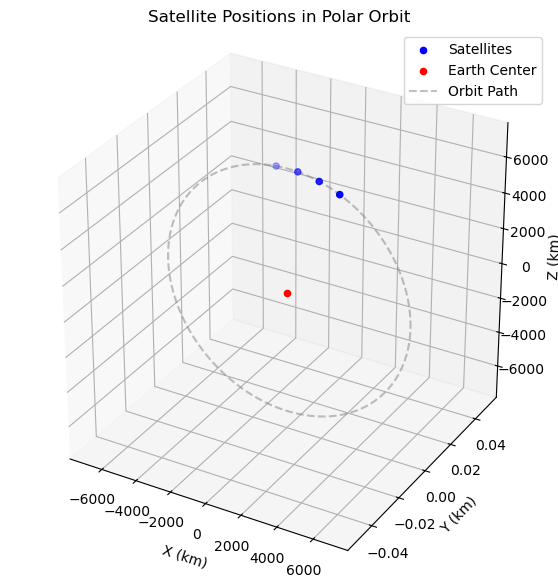

In [8]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot satellites
ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], color='blue', label='Satellites')

# Plot Earth center
ax.scatter(0, 0, 0, color='red', label='Earth Center')

# Draw orbital ring in X-Z plane
theta = np.linspace(0, 2*np.pi, 300)
orbit_radius = 6371 + 510
orbit_x = orbit_radius * np.cos(theta)
orbit_y = np.zeros_like(theta)
orbit_z = orbit_radius * np.sin(theta)
ax.plot(orbit_x, orbit_y, orbit_z, color='gray', linestyle='--', alpha=0.5, label='Orbit Path')

# Labels and view
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_zlabel('Z (km)')
ax.set_title('Satellite Positions in Polar Orbit')
ax.legend()
ax.set_box_aspect([1, 1, 1])
plt.show()

In [3]:
np.random.seed(2)
offset_angle = [10]
angular_spacing = 10
type ="long"
flux_limit = flux_lower_bound(type) # Change flux_limit for long grb = 0.463 and for short grb= 1.861
cat = catalogue(type)
df_results_ = {}
for i, offset in enumerate(offset_angle):
    # sat_pointing = sat_pointing_positions(offset)
    A = 50
    localisation_result = []
    n_det = 0
    total_generate = 0  # Counter for total GRBs generated

    minimum_num_sats_detecting_burst = 3

    while n_det < 50: # change here to set the number of detection
        t_random = np.random.uniform(0, 96 * 60)
        sat_pos = get_satellite_positions(t_random, num_sats=4,angular_spacing_deg= angular_spacing, group_rotation_deg=20)
        lat_lon = eci_to_latlon(sat_pos, t_random)
        pointings, base_dirs = get_pointing_radec(sat_pos,num_sats=4, angular_offset_deg =offset_angle)

        sat_pointing = np.array([coord_transform.r2c(ra, dec) for ra, dec in np.degrees(pointings)])

        grb_vec, ra, dec, t_90, flux_avg = generate_grb(cat)
        
        total_generate += 1

        grb_info = {"ra": ra, 
                "dec":dec, 
                "flux_avg":flux_avg, 
                "t_90": t_90}  
        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
        sat_info = {'sat_pos' : sat_pos,
                'sat_pointing': sat_pointing, 
                'flux_limit': flux_limit,
                'offset': offset,
                'lat_lon':lat_lon}

        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
    
        if sum( det_result[0] > 0 ) >=  minimum_num_sats_detecting_burst :  # Ensure it skips GRBs that do not meet conditions
        
            print(ra, dec)
            n_det += 1
            f_obs, t_obs = det_result
            print("Detection result:", f_obs)

            Ph_obs = np.array([ 0 if f < flux_limit 
                            else np.random.poisson(f * t_90 * A) for f in f_obs])  # Observed Photon count
            
            save_path = os.path.join( f"./orbit_results/aftparasat{angular_spacing}_{type}_grb_plots", f"offset_{offset}", f"detection_{n_det}")
            
            obs_info = {'t_obs': t_obs,
                    'f_obs': f_obs,
                    'Ph_obs': Ph_obs }
        
            mcmc_params= {'steps': 5000, 
                      'nwalk': 8, 
                      'discard': 1000,
                      'move': 2, 
                      'save_path': save_path,
                      'corner_show' :False ,'corner_save' : True, 
                      'chain_show': False, 'chain_save' : True}
            
            localise_params ={'localisation_show' :False, 'localisation_save' :True}
        
            flat_samples = run_mcmc(**grb_info,
                                        **obs_info,
                                        **sat_info,
                                        **mcmc_params)
            
            true_value = np.array([ra, dec, flux_avg])
            
            ci_area_68, containment, area_per_grid_point, std_dev = ci_68_and_sigma(flat_samples,
                                                      true_value, 
                                                      type,
                                                      offset,
                                                      save_path,
                                                      **localise_params)
                                                        

            print(f'RA:{ra},DEC:{dec},FLUX:{flux_avg}')
            print(f"68% confidence region area: {ci_area_68:.2f} deg²")
            print(f"area of grid:{area_per_grid_point}deg²")
            print(f"std_dev:{std_dev}")
            print(f'Localization completed for detection #{n_det}')    
        
            localisation_result.append([ra, dec, t_90, flux_avg, t_random, f_obs, ci_area_68, containment, total_generate])

        df_results_[i] = pd.DataFrame(localisation_result, columns=['RA', 'Dec', 'T90', 'Flux_Avg', 'Time', 'fcos', 'CI_Area_68', 'containment','Total generated'])
    
df_results_[i].to_csv(f'./orbit_results/aftparasat{angular_spacing}_{type}_grb_plots/{type}_{offset}.csv', index=False)
#print(f'Total GRBs generated: {total_generate}, Total detected: {n_det}')

87.40416253879386 7.933473747352824
Detection result: [1.92512638 3.11206434 2.39710171 1.21016375]


100%|██████████| 5000/5000 [00:14<00:00, 340.28it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

100%|██████████| 5000/5000 [00:33<00:00, 151.41it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

68% confidence region area: 0.00 deg²
True value lies within 1σ (68%) confidence region.
RA:85.54362020076144,DEC:46.02352391075889,FLUX:1.700743
68% confidence region area: 0.00 deg²
area of grid:0.149526985392729deg²
std_dev:0.2990534657265442
Localization completed for detection #50


In [ ]:
np.random.seed(2)
offset_angle = [10]
angular_spacing = 10
type ="long"
flux_limit = flux_lower_bound(type) # Change flux_limit for long grb = 0.463 and for short grb= 1.861
cat = catalogue(type)
df_results_ = {}
for i, offset in enumerate(offset_angle):
    # sat_pointing = sat_pointing_positions(offset)
    A = 50
    localisation_result = []
    n_det = 0
    total_generate = 0  # Counter for total GRBs generated

    minimum_num_sats_detecting_burst = 3

    while n_det < 100: # change here to set the number of detection
        t_random = np.random.uniform(0, 96 * 60)
        sat_pos = get_satellite_positions(t_random, num_sats=4,angular_spacing_deg= angular_spacing)
        lat_lon = eci_to_latlon(sat_pos, t_random)
        pointings, base_dirs = get_pointing_radec(sat_pos,num_sats=4, angular_offset_deg =offset_angle)

        sat_pointing = np.array([coord_transform.r2c(ra, dec) for ra, dec in np.degrees(pointings)])

        grb_vec, ra, dec, t_90, flux_avg = generate_grb(cat)
        
        total_generate += 1

        grb_info = {"ra": ra, 
                "dec":dec, 
                "flux_avg":flux_avg, 
                "t_90": t_90}  
        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
        sat_info = {'sat_pos' : sat_pos,
                'sat_pointing': sat_pointing, 
                'flux_limit': flux_limit,
                'offset': offset,
                'lat_lon':lat_lon}

        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
    
        if sum( det_result[0] > 0 ) >=  minimum_num_sats_detecting_burst :  # Ensure it skips GRBs that do not meet conditions
        
            print(ra, dec)
            n_det += 1
            f_obs, t_obs = det_result
            print("Detection result:", f_obs)

            Ph_obs = np.array([ 0 if f < flux_limit 
                            else np.random.poisson(f * t_90 * A) for f in f_obs])  # Observed Photon count
            
            save_path = os.path.join( f"./orbit_results/parasat10_{type}_grb_plots", f"offset_{offset}", f"detection_{n_det}")
            
            obs_info = {'t_obs': t_obs,
                    'f_obs': f_obs,
                    'Ph_obs': Ph_obs }
        
            mcmc_params= {'steps': 5000, 
                      'nwalk': 8, 
                      'discard': 1000,
                      'move': 2, 
                      'save_path': save_path,
                      'corner_show' :True ,'corner_save' : True, 
                      'chain_show': True, 'chain_save' : True}
            
            localise_params ={'localisation_show' :True, 'localisation_save' :True}
        
            flat_samples = run_mcmc(**grb_info,
                                        **obs_info,
                                        **sat_info,
                                        **mcmc_params)
            
            true_value = np.array([ra, dec, flux_avg])
            
            ci_area_68, containment, area_per_grid_point, std_dev = ci_68_and_sigma(flat_samples,
                                                      true_value, 
                                                      type,
                                                      offset,
                                                      save_path,
                                                      **localise_params)
                                                        

            print(f'RA:{ra},DEC:{dec},FLUX:{flux_avg}')
            print(f"68% confidence region area: {ci_area_68:.2f} deg²")
            print(f"area of grid:{area_per_grid_point}deg²")
            print(f"std_dev:{std_dev}")
            print(f'Localization completed for detection #{n_det}')    
        
            localisation_result.append([ra, dec, t_90, flux_avg, t_random, f_obs, ci_area_68, containment, total_generate])

        df_results_[i] = pd.DataFrame(localisation_result, columns=['RA', 'Dec', 'T90', 'Flux_Avg', 'Time', 'fcos', 'CI_Area_68', 'containment','Total generated'])
    
df_results_[i].to_csv(f'./orbit_results/parasat10_{type}_grb_plots/{type}_{offset}.csv', index=False)
#print(f'Total GRBs generated: {total_generate}, Total detected: {n_det}')

In [4]:
arg_perigee = [str(value + 1e-10)[:8] for value in [225, 250, 275]]
constellation = HermesConstellation(pointing_offset_deg = 10 ,
                                    oldest_TLE_time_days = 7,
                                    fake_hermes=True, arg_perigees = arg_perigee)
#constellation.get_pointing_radec()

[#################################] 100% SPIRIT


In [5]:
np.random.seed(1)
offset_angle = [10]
type ="long"
flux_limit = flux_lower_bound(type) # Change flux_limit for long grb = 0.463 and for short grb= 1.861
cat = catalogue(type)
df_results_ = {}
for i, offset in enumerate(offset_angle):
    # sat_pointing = sat_pointing_positions(offset)
    A = 50
    localisation_result = []
    n_det = 0
    total_generate = 0  # Counter for total GRBs generated

    minimum_num_sats_detecting_burst = 3

    while n_det < 1: # change here to set the number of detection
        
        constellation.set_time(random=True)
        grb_time = constellation.time.tt_strftime()
        print(grb_time)
        sat_pos = constellation.get_xyz()
        lat_lon = constellation.get_latlon()
        #print(sat_pos)
        pointings, pointing_group_centres = constellation.get_pointing_radec()
        #print(pointings)
        #print(pointing_group_centres)

        sat_pointing = np.array([coord_transform.r2c(ra, dec) for ra, dec in np.degrees(pointings)])

        grb_vec, ra, dec, t_90, flux_avg = generate_grb(cat)
        
        total_generate += 1

        grb_info = {"ra": ra, 
                "dec":dec, 
                "flux_avg":flux_avg, 
                "t_90": t_90}  
        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
        sat_info = {'sat_pos' : sat_pos,
                'sat_pointing': sat_pointing, 
                'flux_limit': flux_limit,
                'offset': offset,
                'lat_lon':lat_lon}

        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
    
        if sum( det_result[0] > 0 ) >=  minimum_num_sats_detecting_burst :  # Ensure it skips GRBs that do not meet conditions
        
            print(ra, dec)
            n_det += 1
            f_obs, t_obs = det_result
            print("Detection result:", f_obs)

            Ph_obs = np.array([ 0 if f < flux_limit 
                            else np.random.poisson(f * t_90 * A) for f in f_obs])  # Observed Photon count
            
            save_path = os.path.join( f"./orbit_results/4sat25_{type}_grb_plots", f"offset_{offset}", f"detection_{n_det}")
            
            obs_info = {'t_obs': t_obs,
                    'f_obs': f_obs,
                    'Ph_obs': Ph_obs }
        
            mcmc_params= {'steps': 5000, 
                      'nwalk': 8, 
                      'discard': 1000,
                      'move': 2, 
                      'save_path': save_path,
                      'corner_show' : False, 'corner_save' : False, 
                      'chain_show': False, 'chain_save' : False}
            
            localise_params ={'localisation_show' :False, 'localisation_save' :False}
        
            flat_samples = run_mcmc(**grb_info,
                                        **obs_info,
                                        **sat_info,
                                        **mcmc_params)
            
            true_value = np.array([ra, dec, flux_avg])
            
            ci_area_68, containment, area_per_grid_point, std_dev = ci_68_and_sigma(flat_samples,
                                                      true_value, 
                                                      type,
                                                      offset,
                                                      save_path,
                                                      **localise_params)
                                                        

            print(f'RA:{ra},DEC:{dec},FLUX:{flux_avg}')
            print(f"68% confidence region area: {ci_area_68:.2f} deg²")
            print(f"area of grid:{area_per_grid_point}deg²")
            print(f"std_dev:{std_dev}")
            print(f'Localization completed for detection #{n_det}')    
        
            localisation_result.append([ra, dec, t_90, flux_avg, grb_time, f_obs, ci_area_68, containment, total_generate])

        df_results_[i] = pd.DataFrame(localisation_result, columns=['RA', 'Dec', 'T90', 'Flux_Avg', 'Time', 'fcos', 'CI_Area_68', 'containment','Total generated'])
    
df_results_[i].to_csv(f'./orbit_results/4sat25_{type}_grb_plots/{type}_{offset}.csv', index=False)
#print(f'Total GRBs generated: {total_generate}, Total detected: {n_det}')

2025-05-21 08:11:05 TT
2025-05-25 02:14:05 TT
2025-05-18 06:40:48 TT
2025-05-25 02:39:54 TT
2025-05-19 14:44:57 TT
2025-05-16 06:04:57 TT
2025-05-16 22:31:31 TT
2025-05-16 03:23:26 TT
2025-05-20 18:56:35 TT
2025-05-24 10:19:31 TT
2025-05-26 04:25:43 TT
2025-05-22 11:24:38 TT
2025-05-26 07:14:10 TT
2025-05-27 21:37:46 TT
2025-05-28 12:14:00 TT
2025-05-27 06:53:09 TT
2025-05-23 08:32:13 TT
2025-05-23 06:55:43 TT
2025-05-23 15:21:45 TT
2025-05-15 18:24:09 TT
2025-05-19 22:43:23 TT
2025-05-16 10:26:17 TT
2025-05-16 10:30:21 TT
2025-05-22 20:19:43 TT
2025-05-22 07:20:30 TT
2025-05-21 00:44:56 TT
2025-05-19 12:05:54 TT
2025-05-21 13:46:36 TT
2025-05-16 06:15:58 TT
2025-05-26 12:07:38 TT
2025-05-25 06:21:40 TT
2025-05-22 22:40:42 TT
2025-05-26 15:58:50 TT
2025-05-26 17:29:57 TT
2025-05-23 11:09:55 TT
2025-05-16 14:54:03 TT
2025-05-22 00:55:30 TT
2025-05-28 07:49:27 TT
2025-05-18 23:26:43 TT
2025-05-16 22:24:07 TT
2025-05-23 02:49:20 TT
2025-05-22 18:32:35 TT
2025-05-26 06:46:51 TT
2025-05-20 

100%|██████████| 5000/5000 [00:11<00:00, 422.88it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

68% confidence region area: 92.00 deg²
True value lies within 1σ (68%) confidence region.
RA:46.34640767929708,DEC:-39.5068026250998,FLUX:1.738174
68% confidence region area: 92.00 deg²
area of grid:2.486768340466574deg²
std_dev:7.459952018115075
Localization completed for detection #1


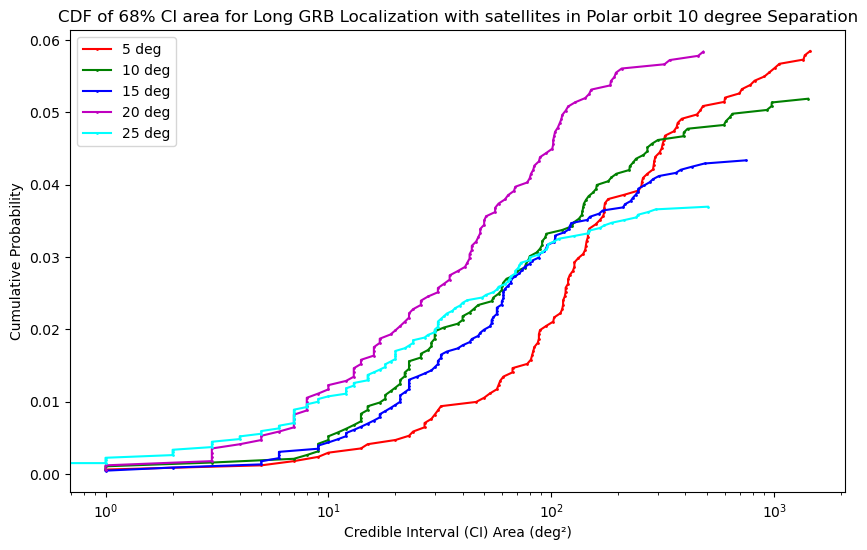

In [32]:
angles = [5,10,15,20,25 ]  
colour = ['red', 'g','b', 'm', 'cyan', 'k', 'y']

# Initialize lists
deg_list = []
sorted_ci_areas_list = []
cdf_list = []

plt.figure(figsize=(10, 6))
plt.xscale('log')
#plt.ylim([0, 0.2]) 

for idx, i in enumerate(angles):
    file_path = f"./orbit_results/4sat10_long_grb_plots/long_{i}.csv"
    
    
    deg = pd.read_csv(file_path)
    deg_list.append(deg)

    
    sorted_ci_areas = np.sort(deg['CI_Area_68'])
    sorted_ci_areas_list.append(sorted_ci_areas)

    total_generated = deg['Total generated'].iloc[-1]
    cdf = np.arange(1, len(sorted_ci_areas) + 1) / total_generated
    cdf_list.append(cdf)

    # Plot 
    plt.plot(sorted_ci_areas, cdf, marker='o', linestyle='-', 
             color=colour[idx], markersize=1, label=f'{i} deg', alpha=1)

plt.xlabel("Credible Interval (CI) Area (deg²)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of 68% CI area for Long GRB Localization with satellites in Polar orbit 10 degree Separation")
plt.legend()

plt.savefig('./orbit_results/4sat10_long_grb_plots/long_grb_10_degree_separation.png')
plt.show()

In [33]:
arg_perigee = [str(value + 1e-10)[:8] for value in [210, 220, 230]]
constellation = HermesConstellation(pointing_offset_deg = 20 ,
                                    oldest_TLE_time_days = 7,
                                    fake_hermes=True, arg_perigees = arg_perigee)
#constellation.get_pointing_radec()

In [34]:
np.random.seed(1)
offset_angle = [20]
type ="long"
flux_limit = flux_lower_bound(type) # Change flux_limit for long grb = 0.463 and for short grb= 1.861
cat = catalogue(type)
df_results_ = {}
for i, offset in enumerate(offset_angle):
    # sat_pointing = sat_pointing_positions(offset)
    A = 50
    localisation_result = []
    n_det = 0
    total_generate = 0  # Counter for total GRBs generated

    minimum_num_sats_detecting_burst = 3

    while n_det < 100: # change here to set the number of detection
        
        constellation.set_time(random=True)
        grb_time = constellation.time.tt_strftime()
        #print(grb_time)
        sat_pos = constellation.get_xyz()
        lat_lon = constellation.get_latlon()
        #print(sat_pos)
        pointings, pointing_group_centres = constellation.get_pointing_radec()
        #print(pointings)
        #print(pointing_group_centres)

        sat_pointing = np.array([coord_transform.r2c(ra, dec) for ra, dec in np.degrees(pointings)])

        grb_vec, ra, dec, t_90, flux_avg = generate_grb(cat)
        
        total_generate += 1

        grb_info = {"ra": ra, 
                "dec":dec, 
                "flux_avg":flux_avg, 
                "t_90": t_90}  
        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
        sat_info = {'sat_pos' : sat_pos,
                'sat_pointing': sat_pointing, 
                'flux_limit': flux_limit,
                'offset': offset,
                'lat_lon':lat_lon}

        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
    
        if sum( det_result[0] > 0 ) >=  minimum_num_sats_detecting_burst :  # Ensure it skips GRBs that do not meet conditions
        
            print(ra, dec)
            n_det += 1
            f_obs, t_obs = det_result
            print("Detection result:", f_obs)

            Ph_obs = np.array([ 0 if f < flux_limit 
                            else np.random.poisson(f * t_90 * A) for f in f_obs])  # Observed Photon count
            
            save_path = os.path.join( f"./orbit_results/4sat10_{type}_grb_plots", f"offset_{offset}", f"detection_{n_det}")
            
            obs_info = {'t_obs': t_obs,
                    'f_obs': f_obs,
                    'Ph_obs': Ph_obs }
        
            mcmc_params= {'steps': 5000, 
                      'nwalk': 8, 
                      'discard': 1000,
                      'move': 2, 
                      'save_path': save_path,
                      'corner_show' : False, 'corner_save' : True, 
                      'chain_show': False, 'chain_save' : True}
            
            localise_params ={'localisation_show' :False, 'localisation_save' :True}
        
            flat_samples = run_mcmc(**grb_info,
                                        **obs_info,
                                        **sat_info,
                                        **mcmc_params)
            
            true_value = np.array([ra, dec, flux_avg])
            
            ci_area_68, containment, area_per_grid_point, std_dev = ci_68_and_sigma(flat_samples,
                                                      true_value, 
                                                      type,
                                                      offset,
                                                      save_path,
                                                      **localise_params)
                                                        

            print(f'RA:{ra},DEC:{dec},FLUX:{flux_avg}')
            print(f"68% confidence region area: {ci_area_68:.2f} deg²")
            print(f"area of grid:{area_per_grid_point}deg²")
            print(f"std_dev:{std_dev}")
            print(f'Localization completed for detection #{n_det}')    
        
            localisation_result.append([ra, dec, t_90, flux_avg, grb_time, f_obs, ci_area_68, containment, total_generate])

        df_results_[i] = pd.DataFrame(localisation_result, columns=['RA', 'Dec', 'T90', 'Flux_Avg', 'Time', 'fcos', 'CI_Area_68', 'containment','Total generated'])
    
df_results_[i].to_csv(f'./orbit_results/4sat10_{type}_grb_plots/{type}_{offset}.csv', index=False)
#print(f'Total GRBs generated: {total_generate}, Total detected: {n_det}')

78.26822668946978 34.03489578497835
Detection result: [0.77891022 0.46401237 0.46401237 0.        ]


100%|██████████| 5000/5000 [00:09<00:00, 554.68it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

100%|██████████| 5000/5000 [00:11<00:00, 422.82it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

68% confidence region area: 19.00 deg²
True value is within 2σ (95%) but not 1σ.
RA:13.083276771209235,DEC:-0.9054034535254161,FLUX:0.9073272
68% confidence region area: 19.00 deg²
area of grid:0.5965036582897134deg²
std_dev:1.78949369738654
Localization completed for detection #100


In [2]:
def flat_sky_offsets(center_ra, center_dec, offset_deg, n_sats):
    """
    Returns (RA, Dec) coordinates for n_sats placed evenly in a circle of radius `offset_deg`
    around a central (RA, Dec), assuming flat-sky geometry.
    """
    pointings = []
    for i in range(n_sats):
        angle_rad = 2 * np.pi * i / n_sats
        ra = center_ra + offset_deg * np.cos(angle_rad)
        dec = center_dec + offset_deg * np.sin(angle_rad)
        pointings.append((ra, dec))
    return pointings

In [7]:
flat_sky_offsets(0,0,10,3)

[(10.0, 0.0),
 (-4.999999999999998, 8.660254037844387),
 (-5.000000000000004, -8.660254037844386)]

In [9]:
spherical_offsets(10,0,0,3)

[(0.0, -10.0),
 (8.682203901046167, 4.980925321928869),
 (351.31779609895386, 4.9809253219288765)]

In [7]:
def spherical_offsets(r_deg,ra0_deg, dec0_deg, n_sats):
    ra0 = np.radians(ra0_deg)
    dec0 = np.radians(dec0_deg)
    r = np.radians(r_deg)

        # Central unit vector
    v0 = np.array([
    np.cos(dec0) * np.cos(ra0),
    np.cos(dec0) * np.sin(ra0),
    np.sin(dec0)
    ])

        # Local tangent basis
    temp = np.array([1, 0, 0]) if abs(v0[0]) < 0.9 else np.array([0, 1, 0])
    u = np.cross(temp, v0)
    u /= np.linalg.norm(u)
    v = np.cross(v0, u)

    ras, decs = [], []

    for i in range(n_sats):
        phi = 2 * np.pi * i / n_sats
        offset_vector = (np.cos(r) * v0 +
                         np.sin(r) * (np.cos(phi) * u + np.sin(phi) * v))

        x, y, z = offset_vector
        dec = np.arcsin(z)
        ra = np.arctan2(y, x)
        ras.append(np.degrees(ra) % 360)
        decs.append(np.degrees(dec))

    #return list(zip(np.radians(ras), np.radians(decs)))
    return list(zip(ras, decs))


2025-05-19 02:33:20 TT
[[ 5946.44292696  2404.6698422  -2347.85716926]
 [ 3149.29108214 -6050.77687192   368.09117404]
 [ 2789.6242659  -6190.34070785  -757.67168159]
 [ 2345.33440864 -6141.94188498 -1860.21683937]]
[[ 8.41728312e-01  4.80916000e-17]
 [ 1.10352770e+00 -2.61799388e-01]
 [ 1.36532709e+00 -1.60305333e-17]
 [ 1.10352770e+00  2.61799388e-01]]
[[0.551763850075413, 0], [3.693356503665206, 0]]
2025-05-22 20:36:20 TT
[[-2817.14117991  1645.46404682  5993.85433611]
 [ -456.87828852  4512.88300457  5097.70968186]
 [  238.95924224  3751.34083226  5694.29798429]
 [  927.48093973  2875.64754447  6117.50752326]]
[[ 1.23929207e+00 -1.60305333e-17]
 [ 7.15693290e-01  4.80916000e-17]
 [ 9.77492678e-01  2.61799388e-01]
 [ 9.77492678e-01 -2.61799388e-01]]
[[0.4887463388438009, 0], [3.630338992433594, 0]]
2025-05-16 01:03:03 TT
[[ 5960.42987276  3328.16568737  -104.34403168]
 [ 3262.67670302 -5361.24473329  2690.90088673]
 [ 3107.17057277 -5861.82065202  1621.90941124]
 [ 2857.17773308 -61

100%|██████████| 5000/5000 [00:09<00:00, 523.64it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

68% confidence region area: 37.00 deg²
True value lies within 1σ (68%) confidence region.


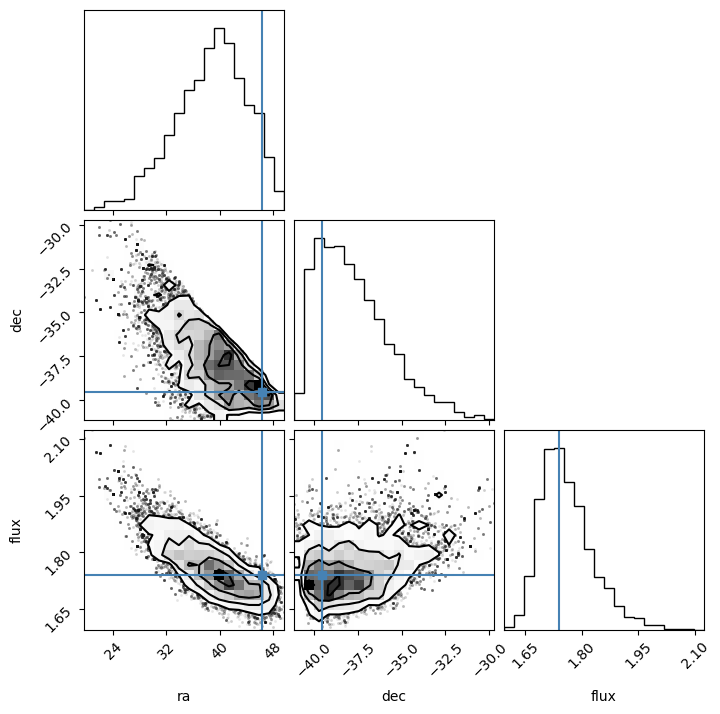

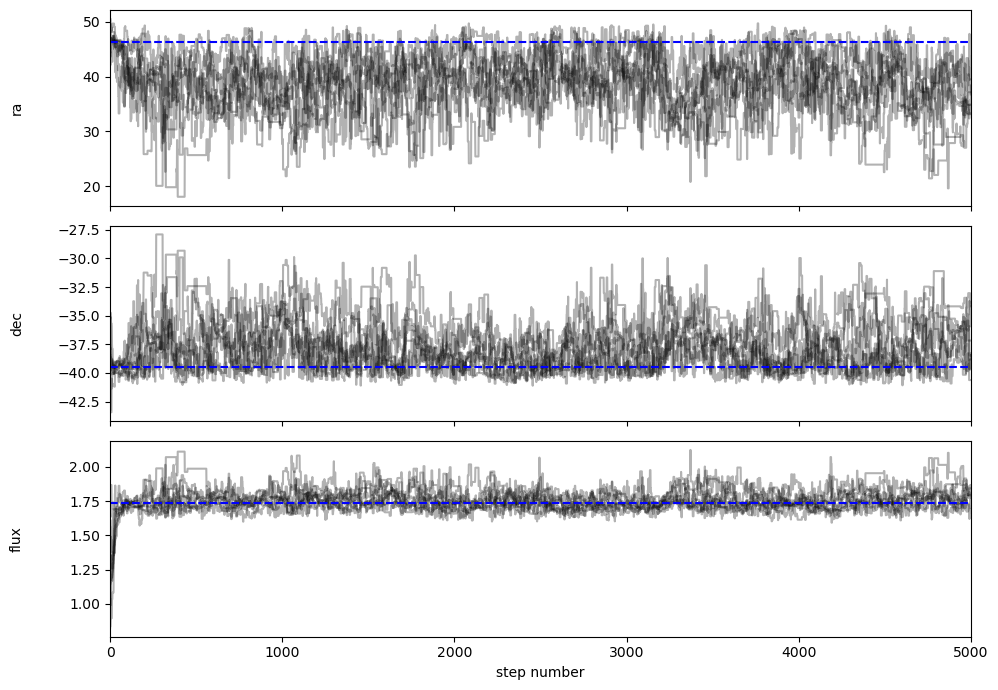

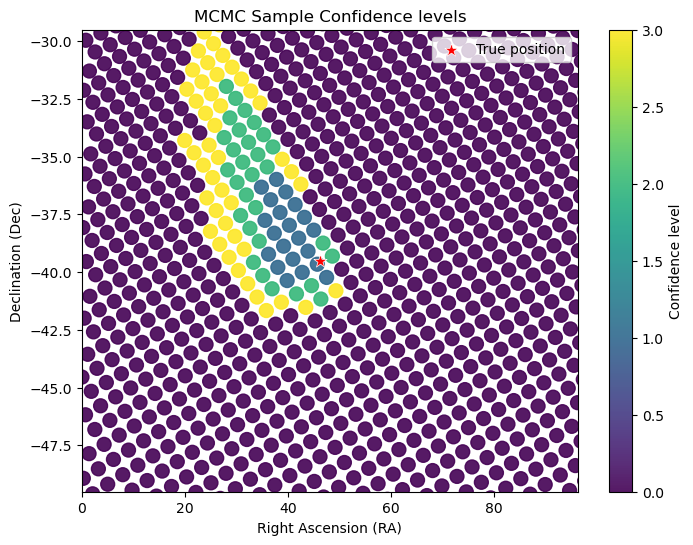

RA:46.34640767929708,DEC:-39.5068026250998,FLUX:1.738174
68% confidence region area: 37.00 deg²
area of grid:1.7723406083519504deg²
std_dev:5.316970799340646
Localization completed for detection #1


In [4]:
np.random.seed(1)
offset_angle = [15]
type ="long"
flux_limit = flux_lower_bound(type) # Change flux_limit for long grb = 0.463 and for short grb= 1.861
cat = catalogue(type)
df_results_ = {}
for i, offset in enumerate(offset_angle):
    # sat_pointing = sat_pointing_positions(offset)
    A = 50
    localisation_result = []
    n_det = 0
    total_generate = 0  # Counter for total GRBs generated

    minimum_num_sats_detecting_burst = 3

    while n_det < 1: # change here to set the number of detection
        
        constellation.set_time(random=True)
        grb_time = constellation.time.tt_strftime()
        print(grb_time)
        sat_pos = constellation.get_xyz()
        lat_lon = constellation.get_latlon()
        print(sat_pos)
        pointings, pointing_group_centres = constellation.get_pointing_radec()
        print(pointings)
        print(pointing_group_centres)

        sat_pointing = np.array([coord_transform.r2c(ra, dec) for ra, dec in np.degrees(pointings)])

        grb_vec, ra, dec, t_90, flux_avg = generate_grb(cat)
        
        total_generate += 1

        grb_info = {"ra": ra, 
                "dec":dec, 
                "flux_avg":flux_avg, 
                "t_90": t_90}  
        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
        sat_info = {'sat_pos' : sat_pos,
                'sat_pointing': sat_pointing, 
                'flux_limit': flux_limit,
                'offset': offset,
                'lat_lon':lat_lon}

        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
    
        if sum( det_result[0] > 0 ) >=  minimum_num_sats_detecting_burst :  # Ensure it skips GRBs that do not meet conditions
        
            print(ra, dec)
            n_det += 1
            f_obs, t_obs = det_result
            print("Detection result:", f_obs)

            Ph_obs = np.array([ 0 if f < flux_limit 
                            else np.random.poisson(f * t_90 * A) for f in f_obs])  # Observed Photon count
            
            save_path = os.path.join( f"./orbit_results/trial20_{type}_grb_plots", f"offset_{offset}", f"detection_{n_det}")
            
            obs_info = {'t_obs': t_obs,
                    'f_obs': f_obs,
                    'Ph_obs': Ph_obs }
        
            mcmc_params= {'steps': 5000, 
                      'nwalk': 8, 
                      'discard': 1000,
                      'move': 2, 
                      'save_path': save_path,
                      'corner_show' : True, 'corner_save' : False, 
                      'chain_show': True, 'chain_save' : False}
            
            localise_params ={'localisation_show' :True, 'localisation_save' :False}
        
            flat_samples = run_mcmc(**grb_info,
                                        **obs_info,
                                        **sat_info,
                                        **mcmc_params)
            
            true_value = np.array([ra, dec, flux_avg])
            
            ci_area_68, containment, area_per_grid_point, std_dev = ci_68_and_sigma(flat_samples,
                                                      true_value, 
                                                      type,
                                                      offset,
                                                      save_path,
                                                      **localise_params)
                                                        

            print(f'RA:{ra},DEC:{dec},FLUX:{flux_avg}')
            print(f"68% confidence region area: {ci_area_68:.2f} deg²")
            print(f"area of grid:{area_per_grid_point}deg²")
            print(f"std_dev:{std_dev}")
            print(f'Localization completed for detection #{n_det}')    
        
            localisation_result.append([ra, dec, t_90, flux_avg, grb_time, f_obs, ci_area_68, containment, total_generate])

        df_results_[i] = pd.DataFrame(localisation_result, columns=['RA', 'Dec', 'T90', 'Flux_Avg', 'Time', 'fcos', 'CI_Area_68', 'containment','Total generated'])
    
#df_results_[i].to_csv(f'./orbit_results/trial20_{type}_grb_plots/{type}_{offset}.csv', index=False)
#print(f'Total GRBs generated: {total_generate}, Total detected: {n_det}')

In [5]:

constellation = HermesConstellation(pointing_offset_deg = 25 ,
                                    oldest_TLE_time_days = 7,
                                    fake_hermes=True)
#constellation.get_pointing_radec()
np.random.seed(1)
offset_angle = [25]
type ="long"
flux_limit = flux_lower_bound(type) # Change flux_limit for long grb = 0.463 and for short grb= 1.861
cat = catalogue(type)
df_results_ = {}
for i, offset in enumerate(offset_angle):
    # sat_pointing = sat_pointing_positions(offset)
    A = 50
    localisation_result = []
    n_det = 0
    total_generate = 0  # Counter for total GRBs generated

    minimum_num_sats_detecting_burst = 3

    while n_det < 100: # change here to set the number of detection
        
        constellation.set_time(random=True)
        grb_time = constellation.time.tt_strftime()
        print(grb_time)
        sat_pos = constellation.get_xyz()
        lat_lon = constellation.get_latlon()
        print(sat_pos)
        pointings, pointing_group_centres = constellation.get_pointing_radec()

        sat_pointing = np.array([coord_transform.r2c(ra, dec) for ra, dec in np.degrees(pointings)])

        grb_vec, ra, dec, t_90, flux_avg = generate_grb(cat)
        
        total_generate += 1

        grb_info = {"ra": ra, 
                "dec":dec, 
                "flux_avg":flux_avg, 
                "t_90": t_90}  
        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
        sat_info = {'sat_pos' : sat_pos,
                'sat_pointing': sat_pointing, 
                'flux_limit': flux_limit,
                'offset': offset,
                'lat_lon':lat_lon}

        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
    
        if sum( det_result[0] > 0 ) >=  minimum_num_sats_detecting_burst :  # Ensure it skips GRBs that do not meet conditions
        
            print(ra, dec)
            n_det += 1
            f_obs, t_obs = det_result
            print("Detection result:", f_obs)

            Ph_obs = np.array([ 0 if f < flux_limit 
                            else np.random.poisson(f * t_90 * A) for f in f_obs])  # Observed Photon count
            
            save_path = os.path.join( f"./orbit_results/trial20_{type}_grb_plots", f"offset_{offset}", f"detection_{n_det}")
            
            obs_info = {'t_obs': t_obs,
                    'f_obs': f_obs,
                    'Ph_obs': Ph_obs }
        
            mcmc_params= {'steps': 5000, 
                      'nwalk': 8, 
                      'discard': 1000,
                      'move': 2, 
                      'save_path': save_path,
                      'corner_show' : False, 'corner_save' : True, 
                      'chain_show': False, 'chain_save' : True}
            
            localise_params ={'localisation_show' : False, 'localisation_save' :True}
        
            flat_samples = run_mcmc(**grb_info,
                                        **obs_info,
                                        **sat_info,
                                        **mcmc_params)
            
            true_value = np.array([ra, dec, flux_avg])
            
            ci_area_68, containment, area_per_grid_point, std_dev = ci_68_and_sigma(flat_samples,
                                                      true_value, 
                                                      type,
                                                      offset,
                                                      save_path,
                                                      **localise_params)
                                                        

            print(f'RA:{ra},DEC:{dec},FLUX:{flux_avg}')
            print(f"68% confidence region area: {ci_area_68:.2f} deg²")
            print(f"area of grid:{area_per_grid_point}deg²")
            print(f"std_dev:{std_dev}")
            print(f'Localization completed for detection #{n_det}')    
        
            localisation_result.append([ra, dec, t_90, flux_avg, grb_time, f_obs, ci_area_68, containment, total_generate])

        df_results_[i] = pd.DataFrame(localisation_result, columns=['RA', 'Dec', 'T90', 'Flux_Avg', 'Time', 'fcos', 'CI_Area_68', 'containment','Total generated'])
    
df_results_[i].to_csv(f'./orbit_results/trial20_{type}_grb_plots/{type}_{offset}.csv', index=False)
#print(f'Total GRBs generated: {total_generate}, Total detected: {n_det}')

2025-04-16 19:51:38 TT
[[-1975.63464645 -3260.48648521 -5677.27623205]
 [-3484.27898565  2338.96193289 -5397.61696585]
 [-3840.06671372  4120.93911521 -3872.62353058]
 [ 2710.65577238  -289.82894919  6257.38846532]
 [ 3485.4958157  -2355.29451467  5378.62697087]
 [ 3839.22356892 -4136.89920071  3849.08303106]
 [-2704.31711677   265.46111964 -6274.62893846]]
2025-04-20 13:54:38 TT
[[ 5304.83449782  2251.52455671  3678.1022939 ]
 [ 4162.7668482  -4959.93471729  2211.1741878 ]
 [ 3685.46110544 -5767.63917188    27.76800842]
 [-4137.35377444  3537.09493425 -4150.18515822]
 [-4165.78076609  4946.29810451 -2236.93008474]
 [-3691.14511139  5758.14843956   -53.58991376]
 [ 4135.90464257 -3544.97754186  4135.94227893]]
2025-04-13 18:21:21 TT
[[-1754.33013298 -3225.52157677 -5770.26343531]
 [-3167.25690456  2196.18921134 -5648.57332836]
 [-3531.17688888  4056.16763116 -4221.55201175]
 [ 2423.37356798   -85.95829537  6380.89105157]
 [ 3168.29065463 -2212.47756511  5630.30836535]
 [ 3530.44276966 

100%|██████████| 5000/5000 [00:12<00:00, 416.51it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

100%|██████████| 5000/5000 [00:11<00:00, 444.54it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

68% confidence region area: 6.00 deg²
True value lies within 1σ (68%) confidence region.
RA:178.39745176154375,DEC:-11.256705045396355,FLUX:2.606716
68% confidence region area: 6.00 deg²
area of grid:0.3721582707852194deg²
std_dev:1.116466485698587
Localization completed for detection #100


In [6]:

constellation = HermesConstellation(pointing_offset_deg = 30 ,
                                    oldest_TLE_time_days = 7,
                                    fake_hermes=True)
#constellation.get_pointing_radec()
np.random.seed(1)
offset_angle = [30]
type ="long"
flux_limit = flux_lower_bound(type) # Change flux_limit for long grb = 0.463 and for short grb= 1.861
cat = catalogue(type)
df_results_ = {}
for i, offset in enumerate(offset_angle):
    # sat_pointing = sat_pointing_positions(offset)
    A = 50
    localisation_result = []
    n_det = 0
    total_generate = 0  # Counter for total GRBs generated

    minimum_num_sats_detecting_burst = 3

    while n_det < 100: # change here to set the number of detection
        
        constellation.set_time(random=True)
        grb_time = constellation.time.tt_strftime()
        print(grb_time)
        sat_pos = constellation.get_xyz()
        lat_lon = constellation.get_latlon()
        print(sat_pos)
        pointings, pointing_group_centres = constellation.get_pointing_radec()

        sat_pointing = np.array([coord_transform.r2c(ra, dec) for ra, dec in np.degrees(pointings)])

        grb_vec, ra, dec, t_90, flux_avg = generate_grb(cat)
        
        total_generate += 1

        grb_info = {"ra": ra, 
                "dec":dec, 
                "flux_avg":flux_avg, 
                "t_90": t_90}  
        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
        sat_info = {'sat_pos' : sat_pos,
                'sat_pointing': sat_pointing, 
                'flux_limit': flux_limit,
                'offset': offset,
                'lat_lon':lat_lon}

        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
    
        if sum( det_result[0] > 0 ) >=  minimum_num_sats_detecting_burst :  # Ensure it skips GRBs that do not meet conditions
        
            print(ra, dec)
            n_det += 1
            f_obs, t_obs = det_result
            print("Detection result:", f_obs)

            Ph_obs = np.array([ 0 if f < flux_limit 
                            else np.random.poisson(f * t_90 * A) for f in f_obs])  # Observed Photon count
            
            save_path = os.path.join( f"./orbit_results/trial20_{type}_grb_plots", f"offset_{offset}", f"detection_{n_det}")
            
            obs_info = {'t_obs': t_obs,
                    'f_obs': f_obs,
                    'Ph_obs': Ph_obs }
        
            mcmc_params= {'steps': 5000, 
                      'nwalk': 8, 
                      'discard': 1000,
                      'move': 2, 
                      'save_path': save_path,
                      'corner_show' : False, 'corner_save' : True, 
                      'chain_show': False, 'chain_save' : True}
            
            localise_params ={'localisation_show' : False, 'localisation_save' :True}
        
            flat_samples = run_mcmc(**grb_info,
                                        **obs_info,
                                        **sat_info,
                                        **mcmc_params)
            
            true_value = np.array([ra, dec, flux_avg])
            
            ci_area_68, containment, area_per_grid_point, std_dev = ci_68_and_sigma(flat_samples,
                                                      true_value, 
                                                      type,
                                                      offset,
                                                      save_path,
                                                      **localise_params)
                                                        

            print(f'RA:{ra},DEC:{dec},FLUX:{flux_avg}')
            print(f"68% confidence region area: {ci_area_68:.2f} deg²")
            print(f"area of grid:{area_per_grid_point}deg²")
            print(f"std_dev:{std_dev}")
            print(f'Localization completed for detection #{n_det}')    
        
            localisation_result.append([ra, dec, t_90, flux_avg, grb_time, f_obs, ci_area_68, containment, total_generate])

        df_results_[i] = pd.DataFrame(localisation_result, columns=['RA', 'Dec', 'T90', 'Flux_Avg', 'Time', 'fcos', 'CI_Area_68', 'containment','Total generated'])
    
df_results_[i].to_csv(f'./orbit_results/trial20_{type}_grb_plots/{type}_{offset}.csv', index=False)
#print(f'Total GRBs generated: {total_generate}, Total detected: {n_det}')

2025-04-16 21:22:19 TT
[[ -574.10498246 -3466.02460581 -5867.33322136]
 [-3068.41458801  1116.47726247 -6007.7754804 ]
 [-3686.00774277  3095.07344184 -4855.4902765 ]
 [ 2082.84905109   984.31825169  6423.8502376 ]
 [ 3070.10948268 -1131.61018877  5991.54872114]
 [ 3686.60493984 -3111.70091898  4834.56418243]
 [-2076.33308335 -1006.04927323 -6437.15964833]]
2025-04-20 15:25:19 TT
[[ 4296.13144568  2762.22949495  4542.82245906]
 [ 4215.57407928 -4181.78118168  3398.05011269]
 [ 4034.49643677 -5362.93595909  1342.94857909]
 [-3885.96098264  2479.31876362 -5062.13751032]
 [-4216.72205705  4166.33703053 -3422.24087643]
 [-4038.67437021  5350.83572665 -1369.10714507]
 [ 3884.38472382 -2486.25004366  5048.94881297]]
2025-04-13 19:52:02 TT
[[ -345.3277541  -3472.73520152 -5882.5791655 ]
 [-2763.03940809   929.63789187 -6186.69772811]
 [-3366.69370641  2977.54451329 -5153.81836126]
 [ 1827.74174812  1218.51783598  6462.34748788]
 [ 2764.39197918  -944.48553533  6171.12303114]
 [ 3367.22025056 

100%|██████████| 5000/5000 [00:15<00:00, 331.77it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

100%|██████████| 5000/5000 [00:32<00:00, 154.81it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

KeyboardInterrupt: 

# Plots

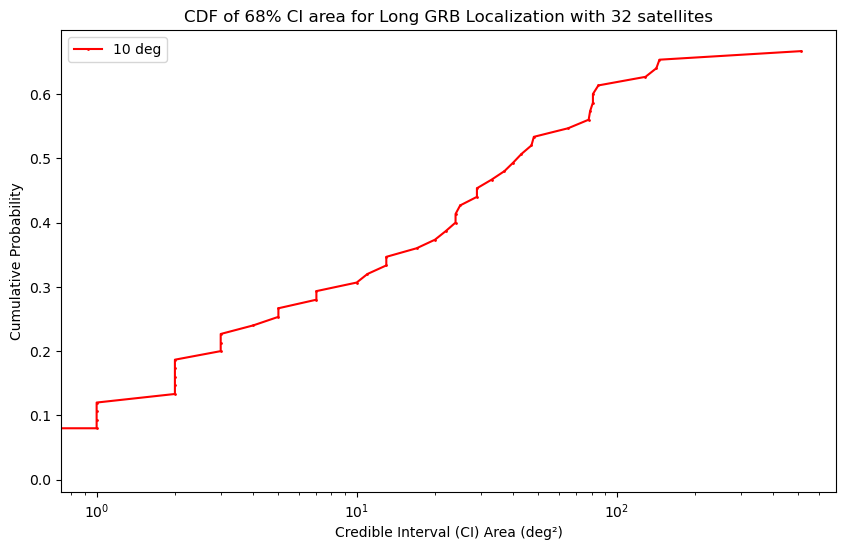

In [4]:
angles = [10]  
colour = ['red', 'g','b', 'm', 'cyan', 'k', 'y']

# Initialize lists
deg_list = []
sorted_ci_areas_list = []
cdf_list = []

plt.figure(figsize=(10, 6))
plt.xscale('log')
#plt.ylim([0, 0.2]) 

for idx, i in enumerate(angles):
    file_path = f"./orbit_results/32_long_grb_plots/long_{i}.csv"
    
    
    deg = pd.read_csv(file_path)
    deg_list.append(deg)

    
    sorted_ci_areas = np.sort(deg['CI_Area_68'])
    sorted_ci_areas_list.append(sorted_ci_areas)

    total_generated = deg['Total generated'].iloc[-1]
    cdf = np.arange(1, len(sorted_ci_areas) + 1) / total_generated
    cdf_list.append(cdf)

    # Plot 
    plt.plot(sorted_ci_areas, cdf, marker='o', linestyle='-', 
             color=colour[idx], markersize=1, label=f'{i} deg', alpha=1)

plt.xlabel("Credible Interval (CI) Area (deg²)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of 68% CI area for Long GRB Localization with 32 satellites")
plt.legend()

#plt.savefig('./orbit_results/8best_long_grb_plots/long_grb_32sat.png')
plt.show()

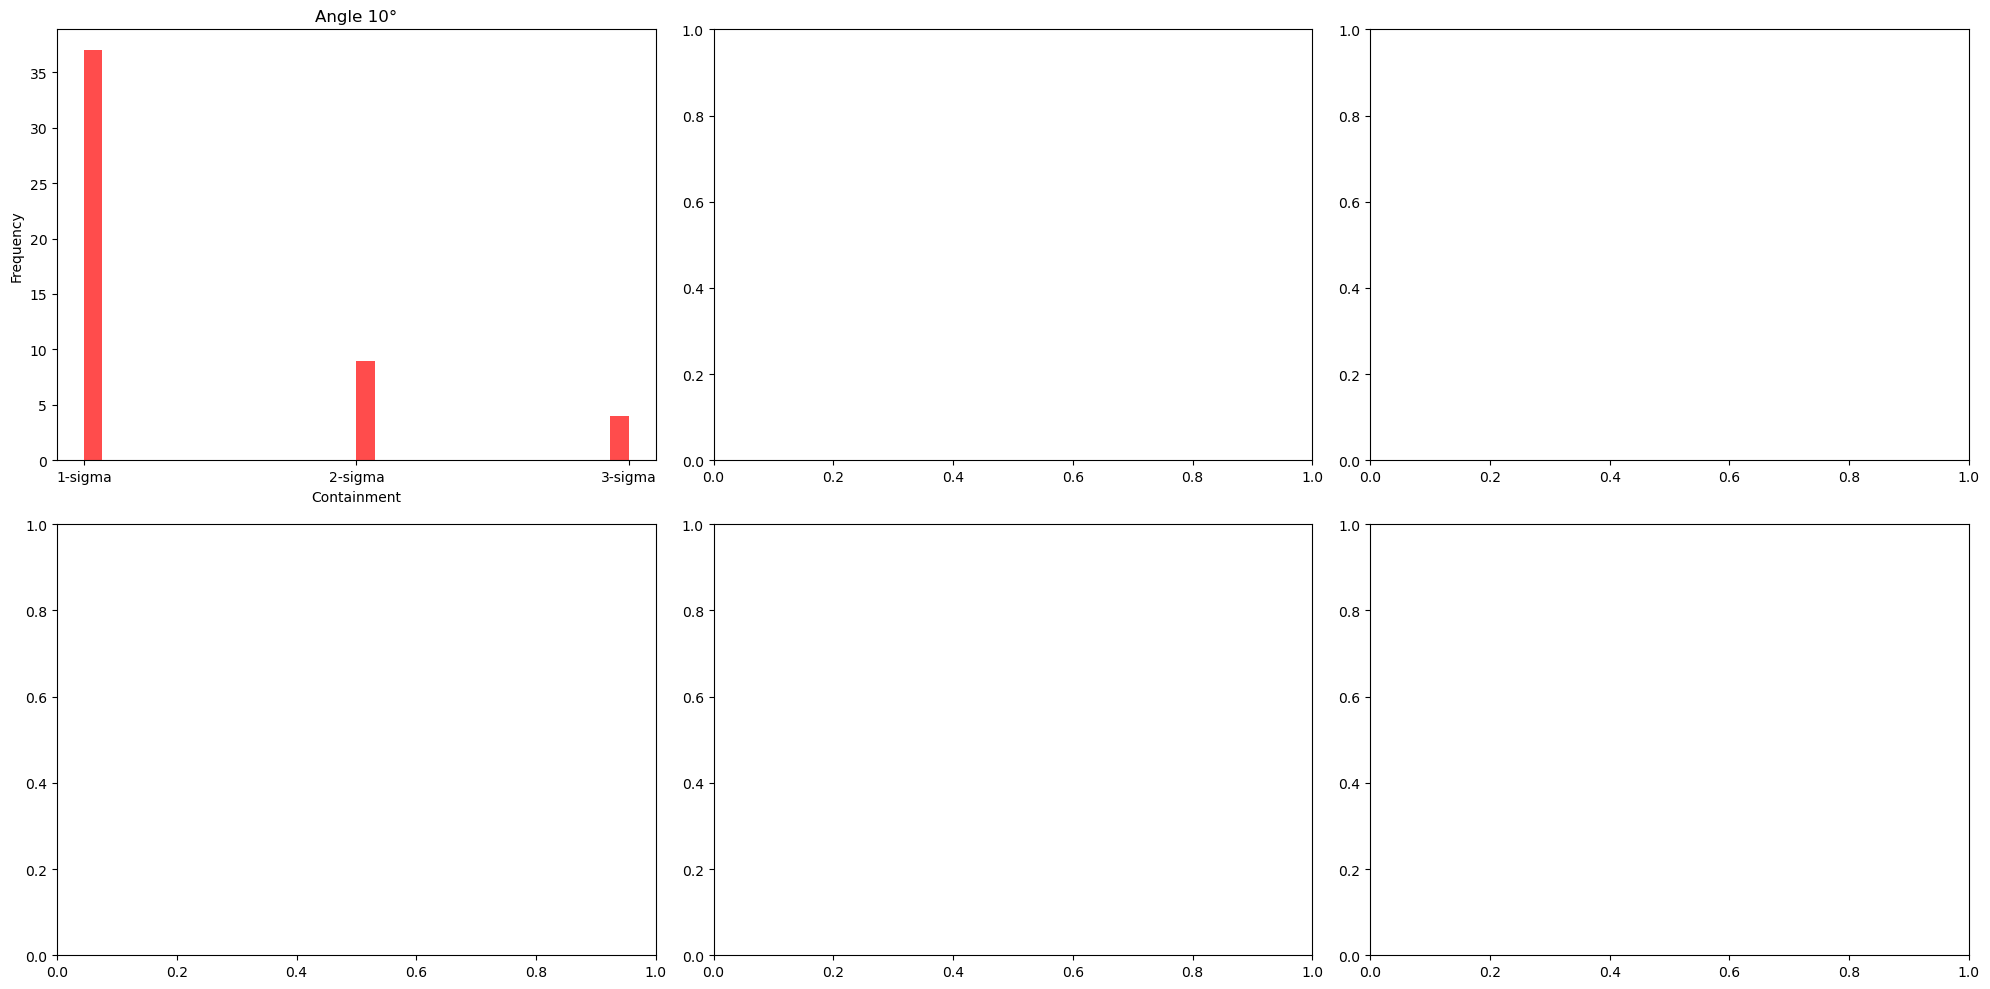

In [7]:
angles = [10]  
colour = ['red', 'green', 'blue', 'magenta', 'cyan', 'orange']  # Added one more color
deg_ = {}

# Create subplots: 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Loop through angles and plot on each subplot
for i, angle in enumerate(angles):
    deg_[angle] = pd.read_csv(f"./orbit_results/8tle_long_grb_plots/long_{angle}.csv")
    
    # Get row and column index
    row, col = divmod(i, 3)
    
    # Plot histogram
    axes[row, col].hist(deg_[angle]['containment'], bins=30, alpha=0.7, color=colour[i])
    axes[row, col].set_title(f'Angle {angle}°')
    axes[row, col].set_xlabel('Containment')
    axes[row, col].set_ylabel('Frequency')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

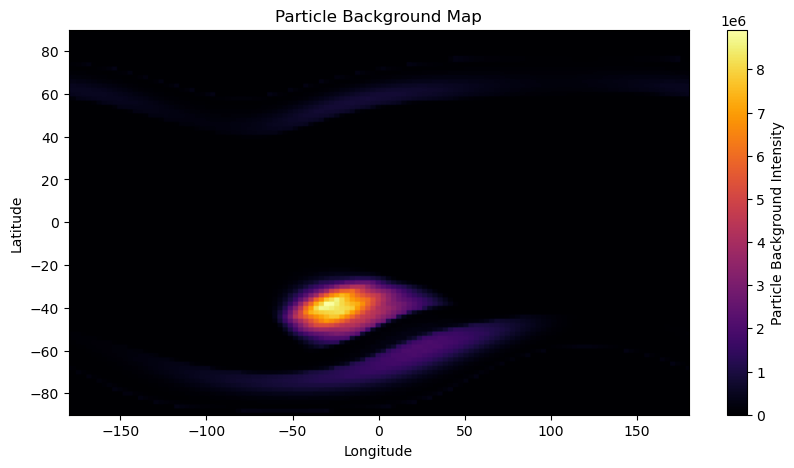

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Load the background data
combined_bkgd = np.load('particle_background.npy')

# Define the lat/lon grid
latitudes = np.arange(-90, 90)  # Assuming 1-degree resolution
longitudes = np.arange(-180, 180)

# Plot the background map
plt.figure(figsize=(10, 5))
plt.imshow(combined_bkgd, extent=[-180, 180, -90, 90], origin='lower', cmap='inferno', aspect='auto')
plt.colorbar(label="Particle Background Intensity")  # Add colorbar
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Particle Background Map")
plt.show()


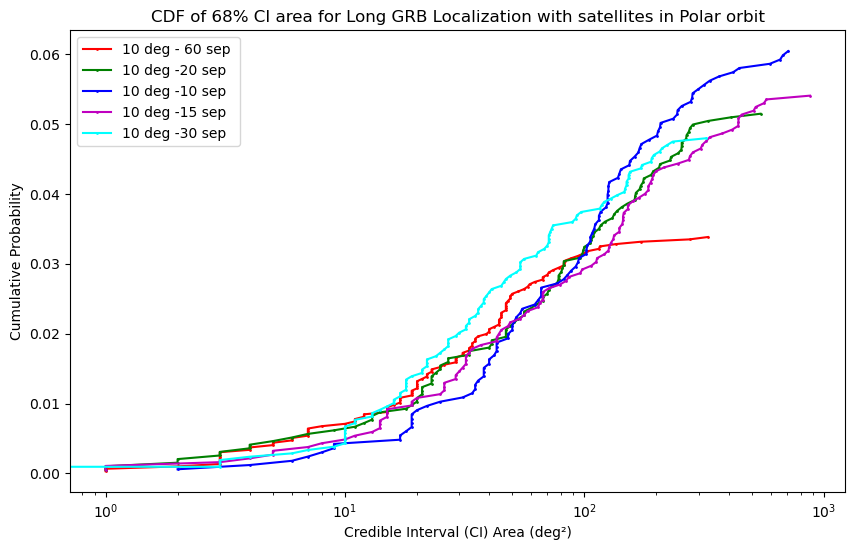

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define angles and colors for plotting
angles = [10]
colour = ['red', 'g', 'b', 'm', 'cyan', 'k', 'y']

# Initialize lists
deg_list = []
sorted_ci_areas_list = []
cdf_list = []

# Create a new figure
plt.figure(figsize=(10, 6))
plt.xscale('log')

# Plot for the first set of data
for idx, i in enumerate(angles):
    file_path = f"./orbit_results/trial_long_grb_plots/long_{i}.csv"
    
    deg = pd.read_csv(file_path)
    deg_list.append(deg)

    sorted_ci_areas = np.sort(deg['CI_Area_68'])
    sorted_ci_areas_list.append(sorted_ci_areas)

    total_generated = deg['Total generated'].iloc[-1]
    cdf = np.arange(1, len(sorted_ci_areas) + 1) / total_generated
    cdf_list.append(cdf)

    # Plot first dataset
    plt.plot(sorted_ci_areas, cdf, marker='o', linestyle='-', 
             color=colour[idx], markersize=1, label=f'{i} deg - 60 sep ', alpha=1)

# Plot for the second set of data
for idx, i in enumerate(angles):
    file_path = f"./orbit_results/trial20_long_grb_plots/long_{i}.csv"
    
    deg = pd.read_csv(file_path)
    deg_list.append(deg)

    sorted_ci_areas = np.sort(deg['CI_Area_68'])
    sorted_ci_areas_list.append(sorted_ci_areas)

    total_generated = deg['Total generated'].iloc[-1]
    cdf = np.arange(1, len(sorted_ci_areas) + 1) / total_generated
    cdf_list.append(cdf)

    # Plot second dataset
    plt.plot(sorted_ci_areas, cdf, marker='o', linestyle='-', 
             color=colour[idx + len(angles)], markersize=1, label=f'{i} deg -20 sep', alpha=1)
    
# Plot for the third set of data
for idx, i in enumerate(angles):
    file_path = f"./orbit_results/trial10_long_grb_plots/long_{i}.csv"
    
    deg = pd.read_csv(file_path)
    deg_list.append(deg)

    sorted_ci_areas = np.sort(deg['CI_Area_68'])
    sorted_ci_areas_list.append(sorted_ci_areas)

    total_generated = deg['Total generated'].iloc[-1]
    cdf = np.arange(1, len(sorted_ci_areas) + 1) / total_generated
    cdf_list.append(cdf)

    # Plot second dataset
    plt.plot(sorted_ci_areas, cdf, marker='o', linestyle='-', 
             color=colour[idx +2], markersize=1, label=f'{i} deg -10 sep', alpha=1)

# Labels, title, and legend
plt.xlabel("Credible Interval (CI) Area (deg²)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of 68% CI area for Long GRB Localization with satellites in Polar orbit")
plt.legend(loc='upper left')

# Plot for the fourth set of data
for idx, i in enumerate(angles):
    file_path = f"./orbit_results/trial15_long_grb_plots/long_{i}.csv"
    
    deg = pd.read_csv(file_path)
    deg_list.append(deg)

    sorted_ci_areas = np.sort(deg['CI_Area_68'])
    sorted_ci_areas_list.append(sorted_ci_areas)

    total_generated = deg['Total generated'].iloc[-1]
    cdf = np.arange(1, len(sorted_ci_areas) + 1) / total_generated
    cdf_list.append(cdf)

    # Plot second dataset
    plt.plot(sorted_ci_areas, cdf, marker='o', linestyle='-', 
             color=colour[idx +3], markersize=1, label=f'{i} deg -15 sep', alpha=1)

# Plot for the fourth set of data
for idx, i in enumerate(angles):
    file_path = f"./orbit_results/trial30_long_grb_plots/long_{i}.csv"
    
    deg = pd.read_csv(file_path)
    deg_list.append(deg)

    sorted_ci_areas = np.sort(deg['CI_Area_68'])
    sorted_ci_areas_list.append(sorted_ci_areas)

    total_generated = deg['Total generated'].iloc[-1]
    cdf = np.arange(1, len(sorted_ci_areas) + 1) / total_generated
    cdf_list.append(cdf)

    # Plot second dataset
    plt.plot(sorted_ci_areas, cdf, marker='o', linestyle='-', 
             color=colour[idx +4], markersize=1, label=f'{i} deg -30 sep', alpha=1)

# Labels, title, and legend
plt.xlabel("Credible Interval (CI) Area (deg²)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of 68% CI area for Long GRB Localization with satellites in Polar orbit")
plt.legend(loc='upper left')

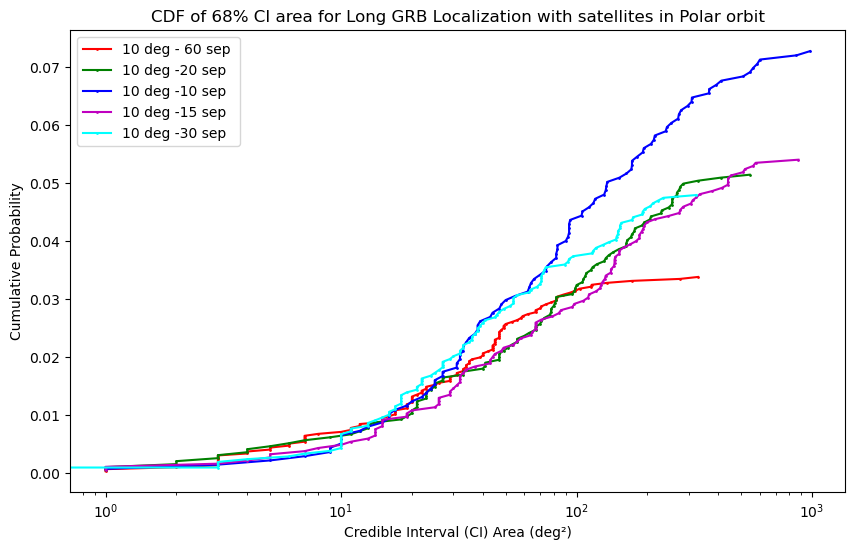

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define angles and colors for plotting
angles = [10]
colour = ['red', 'g', 'b', 'm', 'cyan', 'k', 'y']

# Initialize lists
deg_list = []
sorted_ci_areas_list = []
cdf_list = []

# Create a new figure
plt.figure(figsize=(10, 6))
plt.xscale('log')

# Plot for the first set of data
for idx, i in enumerate(angles):
    file_path = f"./orbit_results/trial_long_grb_plots/long_{i}.csv"
    
    deg = pd.read_csv(file_path)
    deg_list.append(deg)

    sorted_ci_areas = np.sort(deg['CI_Area_68'])
    sorted_ci_areas_list.append(sorted_ci_areas)

    total_generated = deg['Total generated'].iloc[-1]
    cdf = np.arange(1, len(sorted_ci_areas) + 1) / total_generated
    cdf_list.append(cdf)

    # Plot first dataset
    plt.plot(sorted_ci_areas, cdf, marker='o', linestyle='-', 
             color=colour[idx], markersize=1, label=f'{i} deg - 60 sep ', alpha=1)

# Plot for the second set of data
for idx, i in enumerate(angles):
    file_path = f"./orbit_results/trial20_long_grb_plots/long_{i}.csv"
    
    deg = pd.read_csv(file_path)
    deg_list.append(deg)

    sorted_ci_areas = np.sort(deg['CI_Area_68'])
    sorted_ci_areas_list.append(sorted_ci_areas)

    total_generated = deg['Total generated'].iloc[-1]
    cdf = np.arange(1, len(sorted_ci_areas) + 1) / total_generated
    cdf_list.append(cdf)

    # Plot second dataset
    plt.plot(sorted_ci_areas, cdf, marker='o', linestyle='-', 
             color=colour[idx + len(angles)], markersize=1, label=f'{i} deg -20 sep', alpha=1)
    
# Plot for the third set of data
for idx, i in enumerate(angles):
    file_path = f"./orbit_results/trial10_long_grb_plots/long_{i}.csv"
    
    deg = pd.read_csv(file_path)
    deg_list.append(deg)

    sorted_ci_areas = np.sort(deg['CI_Area_68'])
    sorted_ci_areas_list.append(sorted_ci_areas)

    total_generated = deg['Total generated'].iloc[-1]
    cdf = np.arange(1, len(sorted_ci_areas) + 1) / total_generated
    cdf_list.append(cdf)

    # Plot second dataset
    plt.plot(sorted_ci_areas, cdf, marker='o', linestyle='-', 
             color=colour[idx +2], markersize=1, label=f'{i} deg -10 sep', alpha=1)

# Labels, title, and legend
plt.xlabel("Credible Interval (CI) Area (deg²)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of 68% CI area for Long GRB Localization with satellites in Polar orbit")
plt.legend(loc='upper left')

# Plot for the fourth set of data
for idx, i in enumerate(angles):
    file_path = f"./orbit_results/trial15_long_grb_plots/long_{i}.csv"
    
    deg = pd.read_csv(file_path)
    deg_list.append(deg)

    sorted_ci_areas = np.sort(deg['CI_Area_68'])
    sorted_ci_areas_list.append(sorted_ci_areas)

    total_generated = deg['Total generated'].iloc[-1]
    cdf = np.arange(1, len(sorted_ci_areas) + 1) / total_generated
    cdf_list.append(cdf)

    # Plot second dataset
    plt.plot(sorted_ci_areas, cdf, marker='o', linestyle='-', 
             color=colour[idx +3], markersize=1, label=f'{i} deg -15 sep', alpha=1)

# Plot for the fourth set of data
for idx, i in enumerate(angles):
    file_path = f"./orbit_results/trial30_long_grb_plots/long_{i}.csv"
    
    deg = pd.read_csv(file_path)
    deg_list.append(deg)

    sorted_ci_areas = np.sort(deg['CI_Area_68'])
    sorted_ci_areas_list.append(sorted_ci_areas)

    total_generated = deg['Total generated'].iloc[-1]
    cdf = np.arange(1, len(sorted_ci_areas) + 1) / total_generated
    cdf_list.append(cdf)

    # Plot second dataset
    plt.plot(sorted_ci_areas, cdf, marker='o', linestyle='-', 
             color=colour[idx +4], markersize=1, label=f'{i} deg -30 sep', alpha=1)

# Labels, title, and legend
plt.xlabel("Credible Interval (CI) Area (deg²)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of 68% CI area for Long GRB Localization with satellites in Polar orbit")
plt.legend(loc='upper left')

# Save the figure
#plt.savefig('./orbit_results/long_grb_plots/long_grb_comparison.png')
plt.show()

In [8]:
constellation.pointing_strategy.triangle_offset_magnitude

0.1236

In [4]:
np.random.seed(1)
offset_angle = [10]
type ="long"
flux_limit = flux_lower_bound(type) # Change flux_limit for long grb = 0.463 and for short grb= 1.861
cat = catalogue(type)
df_results_ = {}
for i, offset in enumerate(offset_angle):
    # sat_pointing = sat_pointing_positions(offset)
    A = 50
    localisation_result = []
    n_det = 0
    total_generate = 0  # Counter for total GRBs generated

    minimum_num_sats_detecting_burst = 3

    while n_det < 100: # change here to set the number of detection
        
        constellation.set_time(random = True)
        grb_time = constellation.time.tt_strftime()
        sat_pos = constellation.get_xyz()
        lat_lon = constellation.get_latlon()
        pointings, pointing_group_centres = constellation.get_pointing_radec()

        sat_pointing = np.array([coord_transform.r2c(ra, dec) for ra, dec in np.degrees(pointings)])

        grb_vec, ra, dec, t_90, flux_avg = generate_grb(cat)
        
        total_generate += 1

        grb_info = {"ra": ra, 
                "dec":dec, 
                "flux_avg":flux_avg, 
                "t_90": t_90}  
        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
        sat_info = {'sat_pos' : sat_pos,
                'sat_pointing': sat_pointing, 
                'flux_limit': flux_limit,
                'offset': offset,
                'lat_lon':lat_lon}

        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
    
        if sum( det_result[0] > 0 ) >=  minimum_num_sats_detecting_burst :  # Ensure it skips GRBs that do not meet conditions
        
            print(ra, dec)
            n_det += 1
            f_obs, t_obs = det_result
            print("Detection result:", f_obs)

            Ph_obs = np.array([ 0 if f < flux_limit 
                            else np.random.poisson(f * t_90 * A) for f in f_obs])  # Observed Photon count
            
            save_path = os.path.join( f"./orbit_results/trial_{type}_grb_plots", f"offset_{offset}", f"detection_{n_det}")
            
            obs_info = {'t_obs': t_obs,
                    'f_obs': f_obs,
                    'Ph_obs': Ph_obs }
        
            mcmc_params= {'steps': 5000, 
                      'nwalk': 8, 
                      'discard': 1000,
                      'move': 2, 
                      'save_path': save_path,
                      'corner_show' : False, 'corner_save' : True, 
                      'chain_show': False, 'chain_save' : True}
            
            localise_params ={'localisation_show' : False, 'localisation_save' :True}
        
            flat_samples = run_mcmc(**grb_info,
                                        **obs_info,
                                        **sat_info,
                                        **mcmc_params)
            
            true_value = np.array([ra, dec, flux_avg])
            
            ci_area_68, containment, area_per_grid_point, std_dev = ci_68_and_sigma(flat_samples,
                                                      true_value, 
                                                      type,
                                                      offset,
                                                      save_path,
                                                      **localise_params)
                                                        

            print(f'RA:{ra},DEC:{dec},FLUX:{flux_avg}')
            print(f"68% confidence region area: {ci_area_68:.2f} deg²")
            print(f"area of grid:{area_per_grid_point}deg²")
            print(f"std_dev:{std_dev}")
            print(f'Localization completed for detection #{n_det}')    
        
            localisation_result.append([ra, dec, t_90, flux_avg, grb_time, f_obs, ci_area_68, containment, total_generate])

        df_results_[i] = pd.DataFrame(localisation_result, columns=['RA', 'Dec', 'T90', 'Flux_Avg', 'Time', 'fcos', 'CI_Area_68', 'containment','Total generated'])
    
df_results_[i].to_csv(f'./orbit_results/trial_{type}_grb_plots/{type}_{offset}.csv', index=False)
#print(f'Total GRBs generated: {total_generate}, Total detected: {n_det}')

210.43629200911428 11.130352069732421
Detection result: [0.65651769 0.         0.         0.         0.         0.62396225
 0.66268022]


100%|██████████| 5000/5000 [00:13<00:00, 382.04it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

68% confidence region area: 758.00 deg²
True value lies within 1σ (68%) confidence region.
RA:293.4667281591534,DEC:-25.774846640324494,FLUX:1.182112
68% confidence region area: 758.00 deg²
area of grid:3.4337439653737305deg²
std_dev:13.734850514202607
Localization completed for detection #25


Exception: No pointing strategy implemented for a group of 7 satellites.

In [5]:
np.random.seed(1)
offset_angle = [10]
type ="long"
flux_limit = flux_lower_bound(type) # Change flux_limit for long grb = 0.463 and for short grb= 1.861
cat = catalogue(type)
df_results_ = {}
for i, offset in enumerate(offset_angle):
    # sat_pointing = sat_pointing_positions(offset)
    A = 50
    localisation_result = []
    n_det = 0
    total_generate = 0  # Counter for total GRBs generated

    minimum_num_sats_detecting_burst = 3

    while n_det < 100: # change here to set the number of detection
        
        constellation.set_time(random = True)
        grb_time = constellation.time.tt_strftime()
        sat_pos = constellation.get_xyz()
        lat_lon = constellation.get_latlon()
        pointings, pointing_group_centres = constellation.get_pointing_radec()

        sat_pointing = np.array([coord_transform.r2c(ra, dec) for ra, dec in np.degrees(pointings)])

        grb_vec, ra, dec, t_90, flux_avg = generate_grb(cat)
        
        total_generate += 1

        grb_info = {"ra": ra, 
                "dec":dec, 
                "flux_avg":flux_avg, 
                "t_90": t_90}  
        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
        sat_info = {'sat_pos' : sat_pos,
                'sat_pointing': sat_pointing, 
                'flux_limit': flux_limit,
                'offset': offset,
                'lat_lon':lat_lon}

        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
    
        if sum( det_result[0] > 0 ) >=  minimum_num_sats_detecting_burst :  # Ensure it skips GRBs that do not meet conditions
        
            print(ra, dec)
            n_det += 1
            f_obs, t_obs = det_result
            print("Detection result:", f_obs)

            Ph_obs = np.array([ 0 if f < flux_limit 
                            else np.random.poisson(f * t_90 * A) for f in f_obs])  # Observed Photon count
            
            save_path = os.path.join( f"./orbit_results/trial_{type}_grb_plots", f"offset_{offset}", f"detection_{n_det}")
            
            obs_info = {'t_obs': t_obs,
                    'f_obs': f_obs,
                    'Ph_obs': Ph_obs }
        
            mcmc_params= {'steps': 5000, 
                      'nwalk': 8, 
                      'discard': 1000,
                      'move': 2, 
                      'save_path': save_path,
                      'corner_show' : False, 'corner_save' : True, 
                      'chain_show': False, 'chain_save' : True}
            
            localise_params ={'localisation_show' : False, 'localisation_save' :True}
        
            flat_samples = run_mcmc(**grb_info,
                                        **obs_info,
                                        **sat_info,
                                        **mcmc_params)
            
            true_value = np.array([ra, dec, flux_avg])
            
            ci_area_68, containment, area_per_grid_point, std_dev = ci_68_and_sigma(flat_samples,
                                                      true_value, 
                                                      type,
                                                      offset,
                                                      save_path,
                                                      **localise_params)
                                                        

            print(f'RA:{ra},DEC:{dec},FLUX:{flux_avg}')
            print(f"68% confidence region area: {ci_area_68:.2f} deg²")
            print(f"area of grid:{area_per_grid_point}deg²")
            print(f"std_dev:{std_dev}")
            print(f'Localization completed for detection #{n_det}')    
        
            localisation_result.append([ra, dec, t_90, flux_avg, grb_time, f_obs, ci_area_68, containment, total_generate])

        df_results_[i] = pd.DataFrame(localisation_result, columns=['RA', 'Dec', 'T90', 'Flux_Avg', 'Time', 'fcos', 'CI_Area_68', 'containment','Total generated'])
    
df_results_[i].to_csv(f'./orbit_results/trial_{type}_grb_plots/{type}_{offset}.csv', index=False)
#print(f'Total GRBs generated: {total_generate}, Total detected: {n_det}')

6.076916312230407 -7.689264832312576
Detection result: [0.         0.47613406 0.49145345 0.48595137 0.         0.
 0.        ]


100%|██████████| 5000/5000 [00:13<00:00, 367.60it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

68% confidence region area: 413.00 deg²
True value lies within 1σ (68%) confidence region.
RA:62.33699856079613,DEC:21.34503485646757,FLUX:1.520348
68% confidence region area: 413.00 deg²
area of grid:2.1554417681174565deg²
std_dev:8.621485543752192
Localization completed for detection #17


Exception: No pointing strategy implemented for a group of 0 satellites.

In [6]:
pointings, pointing_group_centres = constellation.get_pointing_radec()

Exception: No pointing strategy implemented for a group of 0 satellites.

In [7]:
pointing_group_centres

[[1.2195920019478708, 0], [4.361184655537664, 0]]

In [ ]:
constellation = HermesConstellation(pointing_offset_deg = 20,
                                    oldest_TLE_time_days = 7,
                                    fake_hermes=True)

In [ ]:
np.random.seed(1)
offset_angle = [20]
type ="long"
flux_limit = flux_lower_bound(type) # Change flux_limit for long grb = 0.463 and for short grb= 1.861
cat = catalogue(type)
df_results_ = {}
for i, offset in enumerate(offset_angle):
    # sat_pointing = sat_pointing_positions(offset)
    A = 50
    localisation_result = []
    n_det = 0
    total_generate = 0  # Counter for total GRBs generated

    minimum_num_sats_detecting_burst = 3

    while n_det < 1: # change here to set the number of detection
        
        constellation.set_time(random = True)
        grb_time = constellation.time.tt_strftime()
        sat_pos = constellation.get_xyz()
        lat_lon = constellation.get_latlon()
        pointings, pointing_group_centres = constellation.get_pointing_radec()

        sat_pointing = np.array([coord_transform.r2c(ra, dec) for ra, dec in np.degrees(pointings)])

        grb_vec, ra, dec, t_90, flux_avg = generate_grb(cat)
        
        total_generate += 1

        grb_info = {"ra": ra, 
                "dec":dec, 
                "flux_avg":flux_avg, 
                "t_90": t_90}  
        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
        sat_info = {'sat_pos' : sat_pos,
                'sat_pointing': sat_pointing, 
                'flux_limit': flux_limit,
                'offset': offset,
                'lat_lon':lat_lon}

        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
    
        if sum( det_result[0] > 0 ) >=  minimum_num_sats_detecting_burst :  # Ensure it skips GRBs that do not meet conditions
        
            print(ra, dec)
            n_det += 1
            f_obs, t_obs = det_result
            print("Detection result:", f_obs)

            Ph_obs = np.array([ 0 if f < flux_limit 
                            else np.random.poisson(f * t_90 * A) for f in f_obs])  # Observed Photon count
            
            save_path = os.path.join( f"./orbit_results/trial_{type}_grb_plots", f"offset_{offset}", f"detection_{n_det}")
            
            obs_info = {'t_obs': t_obs,
                    'f_obs': f_obs,
                    'Ph_obs': Ph_obs }
        
            mcmc_params= {'steps': 5000, 
                      'nwalk': 8, 
                      'discard': 1000,
                      'move': 2, 
                      'save_path': save_path,
                      'corner_show' : False, 'corner_save' : True, 
                      'chain_show': False, 'chain_save' : True}
            
            localise_params ={'localisation_show' : False, 'localisation_save' :True}
        
            flat_samples = run_mcmc(**grb_info,
                                        **obs_info,
                                        **sat_info,
                                        **mcmc_params)
            
            true_value = np.array([ra, dec, flux_avg])
            
            ci_area_68, containment, area_per_grid_point, std_dev = ci_68_and_sigma(flat_samples,
                                                      true_value, 
                                                      type,
                                                      offset,
                                                      save_path,
                                                      **localise_params)
                                                        

            print(f'RA:{ra},DEC:{dec},FLUX:{flux_avg}')
            print(f"68% confidence region area: {ci_area_68:.2f} deg²")
            print(f"area of grid:{area_per_grid_point}deg²")
            print(f"std_dev:{std_dev}")
            print(f'Localization completed for detection #{n_det}')    
        
            localisation_result.append([ra, dec, t_90, flux_avg, grb_time, f_obs, ci_area_68, containment, total_generate])

        df_results_[i] = pd.DataFrame(localisation_result, columns=['RA', 'Dec', 'T90', 'Flux_Avg', 'Time', 'fcos', 'CI_Area_68', 'containment','Total generated'])
    
df_results_[i].to_csv(f'./orbit_results/trial_{type}_grb_plots/{type}_{offset}.csv', index=False)
#print(f'Total GRBs generated: {total_generate}, Total detected: {n_det}')

In [38]:
def ang_sep(ra1, dec1, ra2, dec2): #Return angular separation of two points on the sphere in radians
        return np.arccos( np.sin(dec1) * np.sin(dec2) + np.cos(dec1) * np.cos(dec2) * np.cos(ra1 - ra2) )
d = np.arccos(np.sqrt(np.cos(np.radians(10))))
#[-d,d],[d,d][0,-angular_offset]

In [46]:
np.degrees(np.arccos(np.degrees(d)/10))

44.92675672324531

In [42]:
np.degrees(ang_sep(0,0,0,-np.radians(20)))

19.999999999999993

In [ ]:

Group Membership: [1 1 1 0 0 0 1]
Group Offsets: [array([[ 0.    ,  0.1236],
       [-0.1236, -0.1236],
       [ 0.1236, -0.1236]]), array([[ 0.        ,  0.17453293],
       [-0.17453293,  0.        ],
       [ 0.17453293,  0.        ],
       [ 0.        , -0.17453293]])]
153.0240443502637 19.410709408618164
Detection result: [1.46812477 0.9440676  1.32500922 0.         0.         0.
 1.08718314]
100%|██████████| 5000/5000 [00:13<00:00, 372.52it/s]

In [10]:
d

0.12357107792072813

In [23]:
np.degrees(ang_sep(0,0,-d,d))

10.00000000000005

In [28]:
np.degrees(ang_sep(-np.radians(10),0,0,np.radians(10)))

14.10604426056639

In [22]:
ang_sep(-d,d,d,d)

0.24524810877215705

In [21]:
ang_sep(0,np.radians(-10),-d,d)

0.32250962399025246

In [11]:
d=np.arccos(np.sqrt(np.cos(np.radians(10))))

In [ ]:
ang_sep()

Group Membership: [0 0 0 0 1 1]
Group Offsets: [array([[-0.12357108,  0.12357108],
       [ 0.12357108,  0.12357108],
       [ 0.        ,  0.        ],
       [ 0.        , -0.17453293]]), array([[-0.17453293,  0.        ],
       [ 0.17453293,  0.        ]])]
Group Membership: [0 0 0 0 1 1]
Group Offsets: [array([[-0.12357108,  0.12357108],
       [ 0.12357108,  0.12357108],
       [ 0.        ,  0.        ],
       [ 0.        , -0.17453293]]), array([[-0.17453293,  0.        ],
       [ 0.17453293,  0.        ]])]
Group Membership: [0 0 0 0 1 1]
Group Offsets: [array([[-0.12357108,  0.12357108],
       [ 0.12357108,  0.12357108],
       [ 0.        ,  0.        ],
       [ 0.        , -0.17453293]]), array([[-0.17453293,  0.        ],
       [ 0.17453293,  0.        ]])]
Group Membership: [0 0 0 0 1 1]
Group Offsets: [array([[-0.12357108,  0.12357108],
       [ 0.12357108,  0.12357108],
       [ 0.        ,  0.        ],
       [ 0.        , -0.17453293]]), array([[-0.17453293,  0.

100%|██████████| 5000/5000 [00:10<00:00, 458.27it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

68% confidence region area: 293.00 deg²
True value lies within 1σ (68%) confidence region.
RA:61.534826560750545,DEC:-24.31194745092014,FLUX:0.6640734
68% confidence region area: 293.00 deg²
area of grid:2.388293869044173deg²
std_dev:9.552840305710165
Localization completed for detection #1


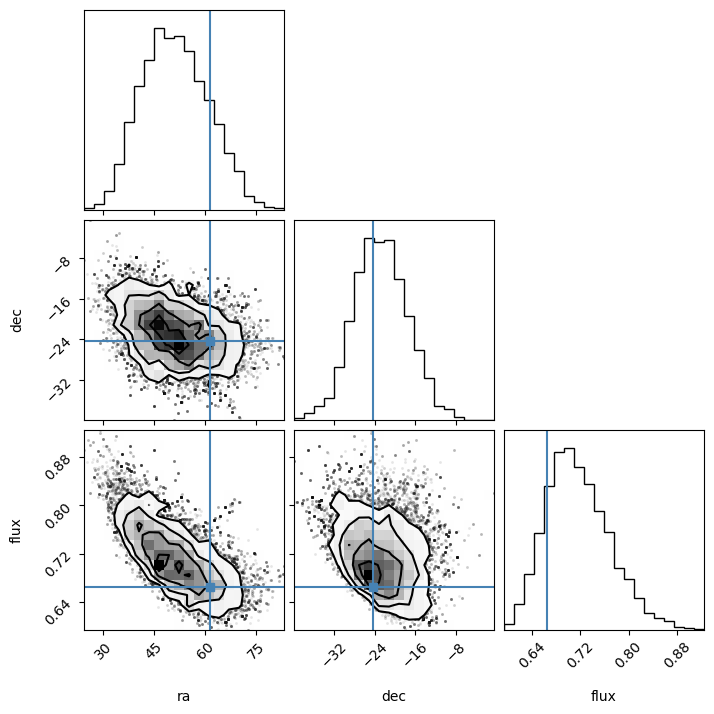

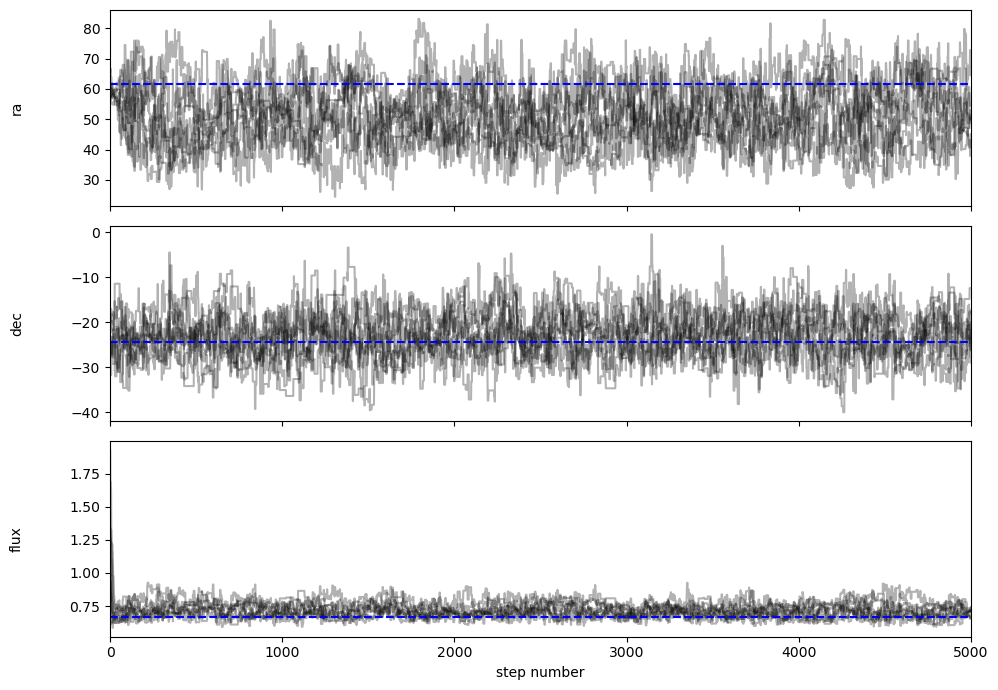

In [4]:
np.random.seed(1)
offset_angle = [10]
type ="long"
flux_limit = flux_lower_bound(type) # Change flux_limit for long grb = 0.463 and for short grb= 1.861
cat = catalogue(type)
df_results_ = {}
for i, offset in enumerate(offset_angle):
    # sat_pointing = sat_pointing_positions(offset)
    A = 50
    localisation_result = []
    n_det = 0
    total_generate = 0  # Counter for total GRBs generated

    minimum_num_sats_detecting_burst = 3

    while n_det < 1: # change here to set the number of detection
        constellation = HermesConstellation(pointing_offset_deg = 10,
                                    oldest_TLE_time_days = 7,
                                    fake_hermes=True)
        constellation.set_time(constellation.ts.now())
        grb_time = constellation.time.tt_strftime()
        sat_pos = constellation.get_xyz()
        lat_lon = constellation.get_latlon()
        pointings, pointing_group_centres = constellation.get_pointing_radec()

        sat_pointing = np.array([coord_transform.r2c(ra, dec) for ra, dec in np.degrees(pointings)])

        grb_vec, ra, dec, t_90, flux_avg = generate_grb(cat)
        
        total_generate += 1

        grb_info = {"ra": ra, 
                "dec":dec, 
                "flux_avg":flux_avg, 
                "t_90": t_90}  
        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
        sat_info = {'sat_pos' : sat_pos,
                'sat_pointing': sat_pointing, 
                'flux_limit': flux_limit,
                'offset': offset,
                'lat_lon':lat_lon}

        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
    
        if sum( det_result[0] > 0 ) >=  minimum_num_sats_detecting_burst :  # Ensure it skips GRBs that do not meet conditions
        
            print(ra, dec)
            n_det += 1
            f_obs, t_obs = det_result
            print("Detection result:", f_obs)

            Ph_obs = np.array([ 0 if f < flux_limit 
                            else np.random.poisson(f * t_90 * A) for f in f_obs])  # Observed Photon count
            
            save_path = os.path.join( f"./orbit_results/trial_{type}_grb_plots", f"offset_{offset}", f"detection_{n_det}")
            
            obs_info = {'t_obs': t_obs,
                    'f_obs': f_obs,
                    'Ph_obs': Ph_obs }
        
            mcmc_params= {'steps': 5000, 
                      'nwalk': 8, 
                      'discard': 1000,
                      'move': 2, 
                      'save_path': save_path,
                      'corner_show' : True, 'corner_save' : False, 
                      'chain_show': True, 'chain_save' : False}
            
            localise_params ={'localisation_show' : False, 'localisation_save' :False}
        
            flat_samples = run_mcmc(**grb_info,
                                        **obs_info,
                                        **sat_info,
                                        **mcmc_params)
            
            true_value = np.array([ra, dec, flux_avg])
            
            ci_area_68, containment, area_per_grid_point, std_dev = ci_68_and_sigma(flat_samples,
                                                      true_value, 
                                                      type,
                                                      offset,
                                                      save_path,
                                                      **localise_params)
                                                        

            print(f'RA:{ra},DEC:{dec},FLUX:{flux_avg}')
            print(f"68% confidence region area: {ci_area_68:.2f} deg²")
            print(f"area of grid:{area_per_grid_point}deg²")
            print(f"std_dev:{std_dev}")
            print(f'Localization completed for detection #{n_det}')    
        
            localisation_result.append([ra, dec, t_90, flux_avg, grb_time, f_obs, ci_area_68, containment, total_generate])

        df_results_[i] = pd.DataFrame(localisation_result, columns=['RA', 'Dec', 'T90', 'Flux_Avg', 'Time', 'fcos', 'CI_Area_68', 'containment','Total generated'])
    
df_results_[i].to_csv(f'./orbit_results/trial_{type}_grb_plots/{type}_{offset}.csv', index=False)
#print(f'Total GRBs generated: {total_generate}, Total detected: {n_det}')

In [ ]:
df_results_[i].to_csv(f'./orbit_results/trial_{type}_grb_plots/{type}_{offset}.csv', index=False)

In [ ]:
lat= 80
lon = 0

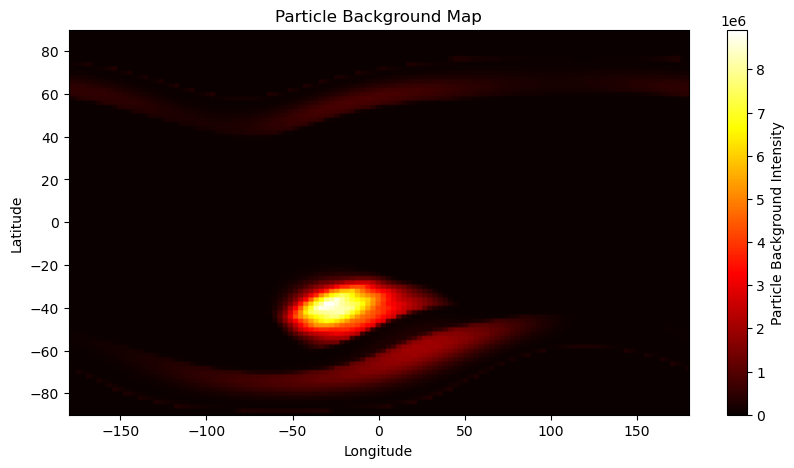

In [7]:

# Load the background data
combined_bkgd = np.load('particle_background.npy')

# Define the lat/lon grid
latitudes = np.arange(-90, 90)  # Assuming 1-degree resolution
longitudes = np.arange(-180, 180)

# Plot the background map
plt.figure(figsize=(10, 5))
plt.imshow(combined_bkgd, extent=[-180, 180, -90, 90], origin='lower', cmap='hot', aspect='auto')
plt.colorbar(label="Particle Background Intensity")  # Add colorbar
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Particle Background Map")
plt.show()

In [ ]:
'''
Basic Usage
'''

from modules.constellation import HermesConstellation, PointingStrategy

# Initialise the constellation object
# -- this automatically loads Spirit's TLE from the celestrak
#    database if the local file is older than the specified
#    number of days

# TODO: once HERMES has launched I'll need to update it to load
#       HERMES in the same way. For now it just makes some fake
#       satellites to represent HERMES in roughly the right orbits.

constellation = HermesConstellation(pointing_offset_deg=20,
                                    oldest_TLE_time_days = 7.0,
                                    fake_hermes=True)
print('-' * 50)
print('Example usage:\n')

# You need to set the time using a datetime object, which we
# can call through the SatelliteConstellation class

current_time = constellation.get_current_time()

constellation.set_time(time = current_time)

print('The current UTC time is:', constellation.time.tt_strftime() )
# .tt_strftime() just converts the time object into human readable format

###

# We can also generate random times up to a few weeks into
# the future (its unwise to go further than this because
# TLE accuracy gets quite bad after about 2 weeks).
#  - we will probably using this random feature the most
#    when generating GRB times for MCMC

constellation.set_time(random = True)

print('Randomly generated time:', constellation.time.tt_strftime() )

# Now that the time is set, we can get the constellation's cartesian
# position and pointing vectors with two easy functions

positions = constellation.get_xyz()
positions

print('\n> Satellite positions at', constellation.time.tt_strftime(), ':')
print(positions)

pointings, pointing_group_centres = constellation.get_pointing_radec()

print('\n> Satellite pointings at', constellation.time.tt_strftime(), ':')
print(pointings)

# Pointings are formatted as ra, dec, where:
#       0 < ra < 2 * pi
#       -pi < dec < pi

 

In [ ]:
positions = constellation.get_latlon()
positions 

In [ ]:
combined_bkgd = np.load('C:\\Users\\Haritha\\repo\\grb_localisation\\mcmc\\particle_background.npy')
def get_particle_background_value(lat, lon):
    """Returns the particle background value at a given (lat, lon) index."""
    lat_idx = int(np.round(lat)) + 90-1
    lon_idx = int(np.round(lon)) + 180-1

    # Ensure indices are within bounds
    
    return combined_bkgd[lat_idx, lon_idx]
   

def get_nonzero_background_indices(positions):
    """Returns the list of indices where positions have nonzero particle background."""
    nonzero_indices = []
    for i, (lat, lon) in enumerate(positions):
        bkgd_value = get_particle_background_value(lat, lon)
        if bkgd_value > 0:
            nonzero_indices.append(i)  # Store the index
    return nonzero_indices

# Get indices of positions with nonzero background
get_nonzero_background_indices(constellation.get_latlon())

In [ ]:
lat_lon = constellation.get_latlon()

In [ ]:
position = constellation.get_latlon()
position

In [ ]:
combined_bkgd = np.load('particle_background.npy')

def particle_background(lat, lon):

    lat = int( np.round( lat ) )
    lon = int( np.round( lon ) )

    bkgd = combined_bkgd[ lat + 90 - 1 ][ lon + 180 - 1 ]
    print(bkgd)

particle_background(lat, lon)

In [ ]:
np.random.seed(1)
offset_angle = [5]
type ="long"
flux_limit = flux_lower_bound(type) # Change flux_limit for long grb = 0.463 and for short grb= 1.861
cat = catalogue(type)
df_results_ = {}
for i, offset in enumerate(offset_angle):
    # sat_pointing = sat_pointing_positions(offset)
    A = 50
    localisation_result = []
    n_det = 0
    total_generate = 0  # Counter for total GRBs generated

    minimum_num_sats_detecting_burst = 3

    while n_det < 100: # change here to set the number of detection
        constellation = HermesConstellation(pointing_offset_deg = 5,
                                    oldest_TLE_time_days = 7,
                                    fake_hermes=True)
        constellation.set_time( constellation.ts.now() + 100)
        grb_time = constellation.time.tt_strftime()
        sat_pos = constellation.get_xyz()
        lat_lon = constellation.get_latlon()
        pointings, pointing_group_centres = constellation.get_pointing_radec()
        sat_pointing = np.array([coord_transform.r2c(ra, dec) for ra, dec in np.degrees(pointings)])

        grb_vec, ra, dec, t_90, flux_avg = generate_grb(cat)
        
        total_generate += 1

        grb_info = {"ra": ra, 
                "dec":dec, 
                "flux_avg":flux_avg, 
                "t_90": t_90}  
        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
        sat_info = {'sat_pos' : sat_pos,
                'sat_pointing': sat_pointing, 
                'flux_limit': flux_limit,
                'offset': offset,
                'lat_lon':lat_lon}

        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit, lat_lon)
    
        if sum( det_result[0] > 0 ) >=  minimum_num_sats_detecting_burst :  # Ensure it skips GRBs that do not meet conditions
        
            print(ra, dec)
            n_det += 1
            f_obs, t_obs = det_result
            #print("Detection result:", det_result)

            Ph_obs = np.array([ 0 if f < flux_limit 
                            else np.random.poisson(f * t_90 * A) for f in f_obs])  # Observed Photon count
            
            save_path = os.path.join( f"./orbit_results/{type}_grb_plots", f"offset_{offset}", f"detection_{n_det}")
            
            obs_info = {'t_obs': t_obs,
                    'f_obs': f_obs,
                    'Ph_obs': Ph_obs }
        
            mcmc_params= {'steps': 5000, 
                      'nwalk': 8, 
                      'discard': 1000,
                      'move': 2, 
                      'save_path': save_path,
                      'corner_show' : True, 'corner_save' : False, 
                      'chain_show': True, 'chain_save' : False}
            
            localise_params ={'localisation_show' : True, 'localisation_save' :False}
        
            flat_samples = run_mcmc(**grb_info,
                                        **obs_info,
                                        **sat_info,
                                        **mcmc_params)
            
            true_value = np.array([ra, dec, flux_avg])
            
            ci_area_68, containment, area_per_grid_point, std_dev = ci_68_and_sigma(flat_samples,
                                                      true_value, 
                                                      type,
                                                      offset,
                                                      save_path,
                                                      **localise_params)
                                                        

            print(f'RA:{ra},DEC:{dec},FLUX:{flux_avg}')
            print(f"68% confidence region area: {ci_area_68:.2f} deg²")
            print(f"area of grid:{area_per_grid_point}deg²")
            print(f"std_dev:{std_dev}")
            print(f'Localization completed for detection #{n_det}')    
        
            localisation_result.append([ra, dec, t_90, flux_avg, grb_time, f_obs, ci_area_68, containment, total_generate])

        df_results_[i] = pd.DataFrame(localisation_result, columns=['RA', 'Dec', 'T90', 'Flux_Avg', 'Time', 'fcos', 'CI_Area_68', 'containment','Total generated'])
    
df_results_[i].to_csv(f'./orbit_results/{type}_grb_plots/{type}_{offset}.csv', index=False)
#print(f'Total GRBs generated: {total_generate}, Total detected: {n_det}')

In [ ]:
angles = [0, 10, 20, 30]  
colour = ['red', 'g','b', 'm', 'cyan', 'k', 'y']

# Initialize lists
deg_list = []
sorted_ci_areas_list = []
cdf_list = []

plt.figure(figsize=(10, 6))
plt.xscale('log')
plt.ylim([0, 0.2]) 

for idx, i in enumerate(angles):
    file_path = f"./orbit_results/long_grb_plots/long_{i}.csv"
    
    
    deg = pd.read_csv(file_path)
    deg_list.append(deg)

    
    sorted_ci_areas = np.sort(deg['CI_Area_68'])
    sorted_ci_areas_list.append(sorted_ci_areas)

    total_generated = deg['Total generated'].iloc[-1]
    cdf = np.arange(1, len(sorted_ci_areas) + 1) / total_generated
    cdf_list.append(cdf)

    # Plot 
    plt.plot(sorted_ci_areas, cdf, marker='o', linestyle='-', 
             color=colour[idx], markersize=1, label=f'{i} deg', alpha=1)

plt.xlabel("Credible Interval (CI) Area (deg²)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of 68% CI area for Long GRB Localization with satellites in Polar orbit")
plt.legend()

plt.savefig('./orbit_results/long_grb_plots/long_grb_100.png')
plt.show()

In [ ]:
np.random.seed(1)
offset_angle = [30]
type ="long"
flux_limit = flux_lower_bound(type) # Change flux_limit for long grb = 0.463 and for short grb= 1.861
cat = catalogue(type)
df_results_ = {}
for i, offset in enumerate(offset_angle):
    # sat_pointing = sat_pointing_positions(offset)
    A = 50
    localisation_result = []
    n_det = 0
    total_generate = 0  # Counter for total GRBs generated

    minimum_num_sats_detecting_burst = 3

    while n_det < 100: # change here to set the number of detection
        constellation = HermesConstellation(pointing_offset_deg = 30,
                                    oldest_TLE_time_days = 7,
                                    fake_hermes=True)
        constellation.set_time( constellation.ts.now() + 100)
        grb_time = constellation.time.tt_strftime()
        sat_pos = constellation.get_xyz()
        pointings, pointing_group_centres = constellation.get_pointing_radec()
        sat_pointing = np.array([coord_transform.r2c(ra, dec) for ra, dec in np.degrees(pointings)])

        grb_vec, ra, dec, t_90, flux_avg = generate_grb(cat)
        
        total_generate += 1

        grb_info = {"ra": ra, 
                "dec":dec, 
                "flux_avg":flux_avg, 
                "t_90": t_90}  
    
        sat_info = {'sat_pos' : sat_pos,
                'sat_pointing': sat_pointing, 
                'flux_limit': flux_limit,
                'offset': offset}

        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit)
    
        if sum( det_result[0] > 0 ) >=  minimum_num_sats_detecting_burst :  # Ensure it skips GRBs that do not meet conditions
        
            print(ra, dec)
            n_det += 1
            f_obs, t_obs = det_result
            #print("Detection result:", det_result)

            Ph_obs = np.array([ 0 if f < flux_limit 
                            else np.random.poisson(f * t_90 * A) for f in f_obs])  # Observed Photon count
            
            save_path = os.path.join( f"./orbit_results/{type}_grb_plots", f"offset_{offset}", f"detection_{n_det}")
            
            obs_info = {'t_obs': t_obs,
                    'f_obs': f_obs,
                    'Ph_obs': Ph_obs }
        
            mcmc_params= {'steps': 5000, 
                      'nwalk': 8, 
                      'discard': 1000,
                      'move': 2, 
                      'save_path': save_path,
                      'corner_show' : False, 'corner_save' : True, 
                      'chain_show': False, 'chain_save' : True}
            
            localise_params ={'localisation_show' : False, 'localisation_save' :True}
        
            flat_samples = run_mcmc(**grb_info,
                                        **obs_info,
                                        **sat_info,
                                        **mcmc_params)
            
            true_value = np.array([ra, dec, flux_avg])
            
            ci_area_68, containment, area_per_grid_point, std_dev = ci_68_and_sigma(flat_samples,
                                                      true_value, 
                                                      type,
                                                      offset,
                                                      save_path,
                                                      **localise_params)
                                                        

            print(f'RA:{ra},DEC:{dec},FLUX:{flux_avg}')
            print(f"68% confidence region area: {ci_area_68:.2f} deg²")
            print(f"area of grid:{area_per_grid_point}deg²")
            print(f"std_dev:{std_dev}")
            print(f'Localization completed for detection #{n_det}')    
        
            localisation_result.append([ra, dec, t_90, flux_avg, grb_time, f_obs, ci_area_68, containment, total_generate])

        df_results_[i] = pd.DataFrame(localisation_result, columns=['RA', 'Dec', 'T90', 'Flux_Avg', 'Time', 'fcos', 'CI_Area_68', 'containment','Total generated'])
    
df_results_[i].to_csv(f'./orbit_results/{type}_grb_plots/{type}_{offset}.csv', index=False)
#print(f'Total GRBs generated: {total_generate}, Total detected: {n_det}')

In [ ]:
np.random.seed(1)
offset_angle = [0]
type ="long"
flux_limit = flux_lower_bound(type) # Change flux_limit for long grb = 0.463 and for short grb= 1.861
cat = catalogue(type)
df_results_ = {}
for i, offset in enumerate(offset_angle):
    # sat_pointing = sat_pointing_positions(offset)
    A = 50
    localisation_result = []
    n_det = 0
    total_generate = 0  # Counter for total GRBs generated

    minimum_num_sats_detecting_burst = 3

    while n_det < 100: # change here to set the number of detection
        constellation = HermesConstellation(pointing_offset_deg = 0,
                                    oldest_TLE_time_days = 7,
                                    fake_hermes=True)
        constellation.set_time( constellation.ts.now() + 100)
        grb_time = constellation.time.tt_strftime()
        sat_pos = constellation.get_xyz()
        pointings, pointing_group_centres = constellation.get_pointing_radec()
        sat_pointing = np.array([coord_transform.r2c(ra, dec) for ra, dec in np.degrees(pointings)])

        grb_vec, ra, dec, t_90, flux_avg = generate_grb(cat)
        
        total_generate += 1

        grb_info = {"ra": ra, 
                "dec":dec, 
                "flux_avg":flux_avg, 
                "t_90": t_90}  
    
        sat_info = {'sat_pos' : sat_pos,
                'sat_pointing': sat_pointing, 
                'flux_limit': flux_limit,
                'offset': offset}

        det_result = simulate_satellite_det(grb_vec, flux_avg, sat_pos, sat_pointing, flux_limit)
    
        if sum( det_result[0] > 0 ) >=  minimum_num_sats_detecting_burst :  # Ensure it skips GRBs that do not meet conditions
        
            print(ra, dec)
            n_det += 1
            f_obs, t_obs = det_result
            #print("Detection result:", det_result)

            Ph_obs = np.array([ 0 if f < flux_limit 
                            else np.random.poisson(f * t_90 * A) for f in f_obs])  # Observed Photon count
            
            save_path = os.path.join( f"./orbit_results/{type}_grb_plots", f"offset_{offset}", f"detection_{n_det}")
            
            obs_info = {'t_obs': t_obs,
                    'f_obs': f_obs,
                    'Ph_obs': Ph_obs }
        
            mcmc_params= {'steps': 5000, 
                      'nwalk': 8, 
                      'discard': 1000,
                      'move': 2, 
                      'save_path': save_path,
                      'corner_show' : False, 'corner_save' : True, 
                      'chain_show': False, 'chain_save' : True}
            
            localise_params ={'localisation_show' : False, 'localisation_save' :True}
        
            flat_samples = run_mcmc(**grb_info,
                                        **obs_info,
                                        **sat_info,
                                        **mcmc_params)
            
            true_value = np.array([ra, dec, flux_avg])
            
            ci_area_68, containment, area_per_grid_point, std_dev = ci_68_and_sigma(flat_samples,
                                                      true_value, 
                                                      type,
                                                      offset,
                                                      save_path,
                                                      **localise_params)
                                                        

            print(f'RA:{ra},DEC:{dec},FLUX:{flux_avg}')
            print(f"68% confidence region area: {ci_area_68:.2f} deg²")
            print(f"area of grid:{area_per_grid_point}deg²")
            print(f"std_dev:{std_dev}")
            print(f'Localization completed for detection #{n_det}')    
        
            localisation_result.append([ra, dec, t_90, flux_avg, grb_time, f_obs, ci_area_68, containment, total_generate])

        df_results_[i] = pd.DataFrame(localisation_result, columns=['RA', 'Dec', 'T90', 'Flux_Avg', 'Time', 'fcos', 'CI_Area_68', 'containment','Total generated'])
    
df_results_[i].to_csv(f'./orbit_results/{type}_grb_plots/{type}_{offset}.csv', index=False)
#print(f'Total GRBs generated: {total_generate}, Total detected: {n_det}')